# Purpose: This notebook is to investigate and summary the discrepancy between fast and slow

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import classification_report

from spnc import spnc_anisotropy
import spnc_ml as ml
from contextmanager import no_print

from scipy import stats

def NRMSE(Y,Y_pred):
    var = np.var(Y)
    return np.sqrt(np.square(Y_pred-Y).mean()/var)

def NRMSE_list(y,y_pred):
    Y = np.array(y)
    Y_pred = np.array(y_pred)
    return(NRMSE(Y,Y_pred))

def NARMA(u, N = 10, a=0.3, b=0.05, d=0.1, e=1.5, g=None):
    y = np.zeros_like(u)
    M = len(u)
    np.seterr(all = 'raise')
    for t in range(10, M):
        try:
            y[t] = y[t-1]*(a + b*np.sum(y[t-N:t])) + e*u[t-N]*u[t-1] + d
            if g is not None:
                y[t] = g(y[t])
        except FloatingPointError:
            print(t, y[t])
            exit()

    return y

def NARMA10(N, seed = None):

    rng = np.random.default_rng(seed)

    Nw = 1000
    u = rng.uniform(0.0, 0.5, N+Nw)
    y = NARMA(u, N=10)

    if not np.isfinite(y).all():
        u = rng.uniform(0.0, 0.5, N+Nw)
        y = NARMA(u, N=10)

    return np.expand_dims(u[Nw:], axis=1), np.expand_dims(y[Nw:], axis=1)

# What is the problem?  - different results from two calculation ways

seed warmup: 1234
length warmup: 0
seed NARMA: 1234
Nwarmup: 0
Samples for training:  2000
Samples for test:  1000
Nin = 1 , Nout =  2000 , Nvirt =  40
Deterministic mask will be used
1234
current phase: warmup
p1 in warmup & slow: 0.4999998889492148
current phase: train
p1 in train & slow: 0.4999998889492148
noise_seed: 1234
noise_mean_train: 0.0001
noise-free training output
restarted
Training data size:  80000
Training data shape:  (2000, 40)
Seed Training: 1234
External net will not be used
current phase: test
p1 in test & slow: 0.4999998889492148
noise_seed: 1234
noise_mean_test: 0.0001
noise-free testing output
restarted
Spacer NRMSE:0
0.005249858147796289 0.654718691125495


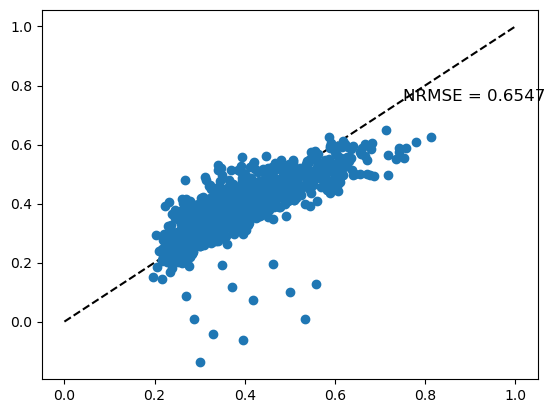

seed warmup: 1234
length warmup: 0
seed NARMA: 1234
Nwarmup: 0
Samples for training:  2000
Samples for test:  1000
Nin = 1 , Nout =  2000 , Nvirt =  40
Deterministic mask will be used
1234
current phase: warmup
p1 in warmup & fast: 0.4999998889492148
current phase: train
p1 in train & fast: 0.4999998889492148
noise-free training output
restarted
Training data size:  80000
Training data shape:  (2000, 40)
Seed Training: 1234
External net will not be used
current phase: test
p1 in test & fast: 0.4999998889492148
noise-free testing output
restarted
Spacer NRMSE:0
0.004155719694704212 0.5825109294768851


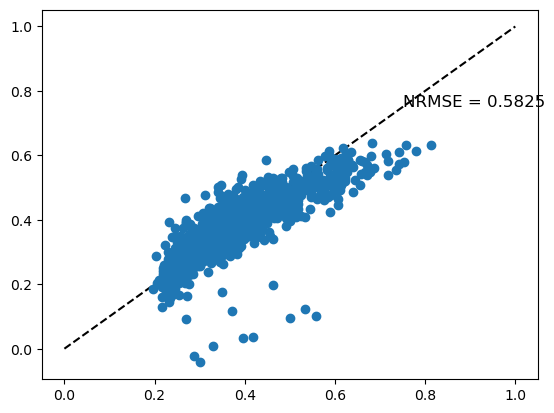

In [2]:
# NARMA10 parameters
Ntrain = 2000
Ntest = 1000
Nwarmup = 0

# Net parameters
Nvirt = 40
m0 = 1e-2
bias = True

# Reservoir parameters
h = 0.4
theta_H = 90
k_s_0 = 0
phi = 45
beta_prime = 10

# Params
params = {
    'theta':1/3, 
    'gamma':.25, 
    'delay_feedback':0, 
    'Nvirt':Nvirt,
    'noise_enable': 'None',
    'noise_seed': 1234,
    'noise_mean':0.0001,
    'noise_std':0.00013,
    'seed_warmup': 1234,
    'length_warmup': Nwarmup,
    'train_sample': Ntrain*Nvirt,
    'test_sample': Ntest*Nvirt,
    'warmup_sample': Nwarmup*Nvirt,
}

spn = spnc_anisotropy(h, theta_H, k_s_0, phi, beta_prime,restart = True,Primep1=None)
transforms = spn.gen_signal_slow_delayed_feedback   
transformf = spn.gen_signal_fast_delayed_feedback

# run
(nrmses,y_test,y_s,y_train,s_s,net_s) = ml.spnc_narma10_weight(Ntrain,Ntest,Nvirt,m0,bias,transforms,params,seed_NARMA=1234,fixed_mask=True,return_all=True, Nwarmup=0)
(nrmsef,y_test,y_f,y_train,s_f,net_f) = ml.spnc_narma10_weight(Ntrain,Ntest,Nvirt,m0,bias,transformf,params,seed_NARMA=1234,fixed_mask=True,return_all=True, Nwarmup=0)

Result: Fast's performance is better than that of slow under the same parameters.

# (ML) The difference in output between two ways

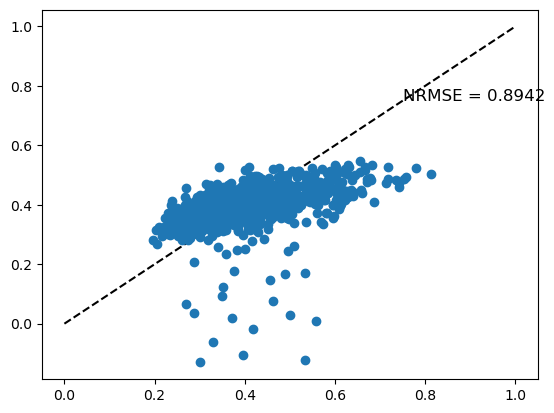

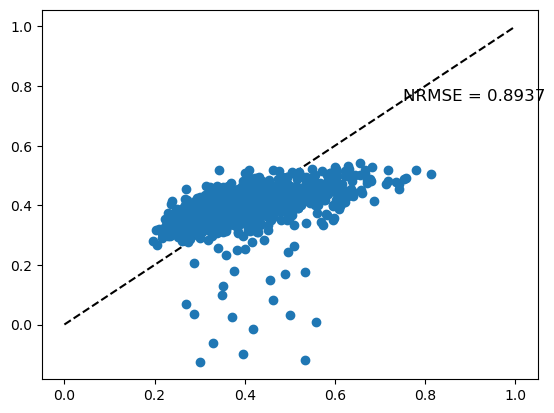

In [27]:
# NARMA10 parameters
Ntrain = 2000
Ntest = 1000
Nwarmup = 0

# Net parameters
Nvirt = 1
m0 = 0.003
bias = True

# Reservoir parameters
h = 0.4
theta_H = 90
k_s_0 = 0
phi = 45
beta_prime = 10

# Params
params = {
    'theta':1/3, 
    'gamma':.25, 
    'delay_feedback':0, 
    'Nvirt':Nvirt,
    'noise_enable': 'None',
    'noise_seed': 1234,
    'noise_mean':0.0001,
    'noise_std':0.00013,
    'seed_warmup': 1234,
    'length_warmup': Nwarmup,
    'train_sample': Ntrain*Nvirt,
    'test_sample': Ntest*Nvirt,
    'warmup_sample': Nwarmup*Nvirt,
}

spn = spnc_anisotropy(h, theta_H, k_s_0, phi, beta_prime,restart = True,Primep1=None)
transforms = spn.gen_signal_slow_delayed_feedback   
transformf = spn.gen_signal_fast_delayed_feedback

# run
with no_print(): 
    (nrmses_nv1,y_test_nv1,y_s_nv1,y_train_nv1,s_s_nv1,net_s_nv1) = ml.spnc_narma10_weight(Ntrain,Ntest,Nvirt,m0,bias,transforms,params,seed_NARMA=1234,fixed_mask=True,return_all=True, Nwarmup=0)
    (nrmsef_nv1,y_test_nv1,y_f_nv1,y_train_nv1,s_f_nv1,net_f_nv1) = ml.spnc_narma10_weight(Ntrain,Ntest,Nvirt,m0,bias,transformf,params,seed_NARMA=1234,fixed_mask=True,return_all=True, Nwarmup=0)

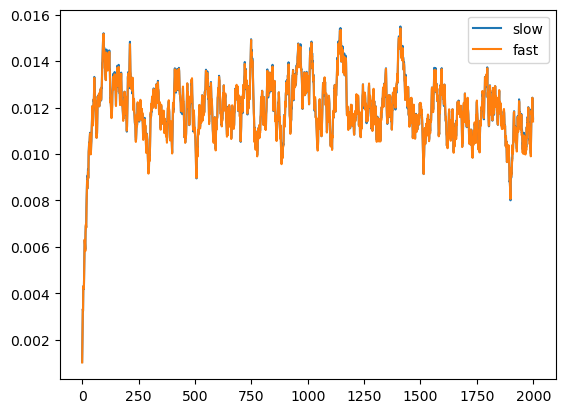

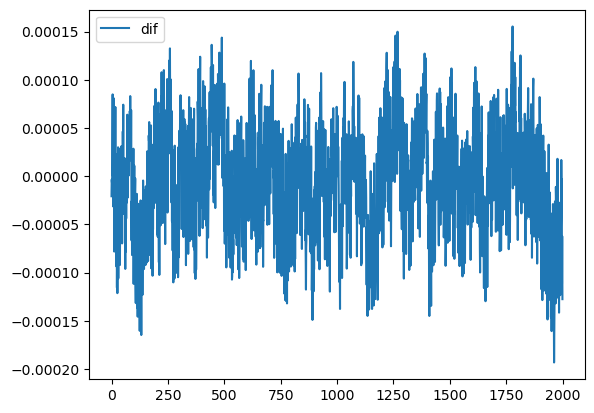

In [28]:
spac = 0
windows = 2000
plt.figure()
# plt.plot(y_train_nv1[spac:spac+windows],label='target')
plt.plot(s_s_nv1[spac:spac+windows],label='slow')
plt.plot(s_f_nv1[spac:spac+windows],label='fast')
plt.legend()
plt.show()

dif = s_f_nv1-s_s_nv1
plt.figure()
plt.plot(dif[spac:spac+windows],label='dif')
plt.legend()
plt.show()

# (Maths) The difference in output between two ways

## NARMA10 data

In [29]:
# NARMA10 parameters
Ntrain = 2000
Ntest = 1000
Nwarmup = 0

# Net parameters
Nvirt = 40
m0 = 1e-2
bias = True

# Reservoir parameters
h = 0.4
theta_H = 90
k_s_0 = 0
phi = 45
beta_prime = 10

# Params
params = {
    'theta':1/3, 
    'gamma':.25, 
    'delay_feedback':0, 
    'Nvirt':Nvirt,
    'noise_enable': 'None',
    'noise_seed': 1234,
    'noise_mean':0.0001,
    'noise_std':0.00013,
    'seed_warmup': 1234,
    'length_warmup': Nwarmup,
    'train_sample': Ntrain*Nvirt,
    'test_sample': Ntest*Nvirt,
    'warmup_sample': Nwarmup*Nvirt,
}

u, d = NARMA10(Nwarmup + Ntrain + Ntest,seed=1234)

x_train = u[Nwarmup:Nwarmup+Ntrain]
y_train = d[Nwarmup:Nwarmup+Ntrain]
x_test = u[Nwarmup+Ntrain:]
y_test = d[Nwarmup+Ntrain:]
c = u[:Nwarmup]
l = d[:Nwarmup]

spns = spnc_anisotropy(h, theta_H, k_s_0, phi, beta_prime,restart = True,Primep1=None)
spnf = spnc_anisotropy(h, theta_H, k_s_0, phi, beta_prime,restart = True,Primep1=None)
mags = spns.slow_calculate(x_train,params)   
magf = spnf.fast_calculate(x_train,params)



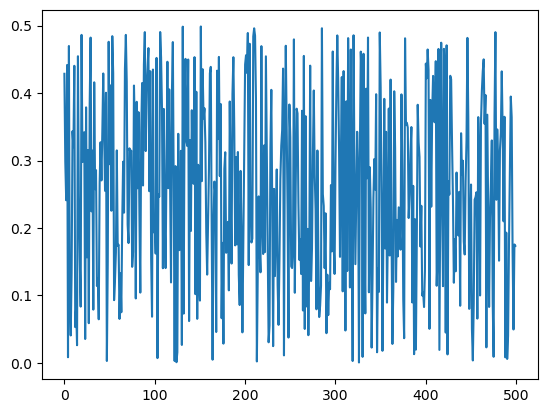

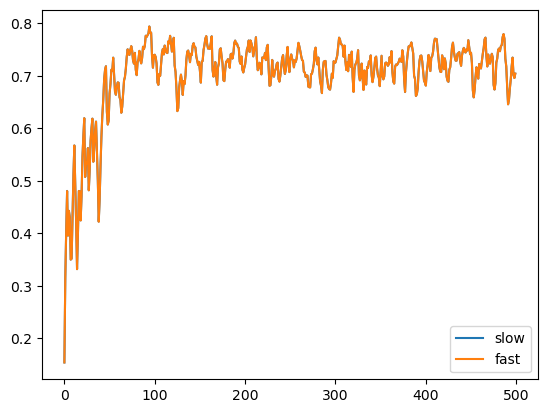

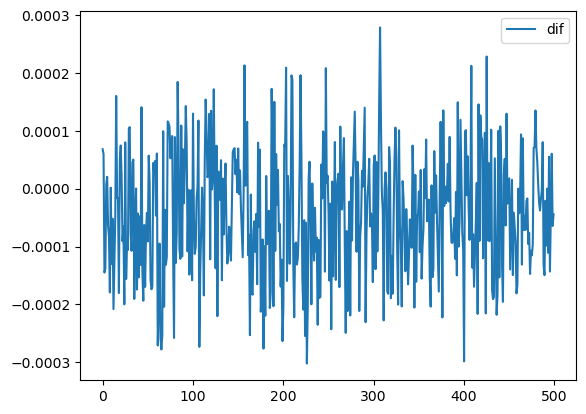

0.0023950494843719824


In [30]:
spac = 0
windows = 500

plt.figure()
plt.plot(x_train[spac:spac+windows],label='target')
plt.show()

plt.figure()
plt.plot(mags[spac:spac+windows],label='slow')
plt.plot(magf[spac:spac+windows],label='fast')
plt.legend()
plt.show()

dif = magf-mags
plt.figure()
plt.plot(dif[spac:spac+windows],label='dif')
plt.legend()
plt.show()

print(NRMSE_list(magf,mags))

## Linear data

In [16]:
# NARMA10 parameters
Ntrain = 2000
Ntest = 1000
Nwarmup = 0

# Net parameters
Nvirt = 40
m0 = 1e-2
bias = True

# Reservoir parameters
h = 0.4
theta_H = 90
k_s_0 = 0
phi = 45
beta_prime = 10

# Params
params = {
    'theta':1/3, 
    'gamma':.25, 
    'delay_feedback':0, 
    'Nvirt':Nvirt,
    'noise_enable': 'None',
    'noise_seed': 1234,
    'noise_mean':0.0001,
    'noise_std':0.00013,
    'seed_warmup': 1234,
    'length_warmup': Nwarmup,
    'train_sample': Ntrain*Nvirt,
    'test_sample': Ntest*Nvirt,
    'warmup_sample': Nwarmup*Nvirt,
}

x_train = np.linspace(0,0.5,2000)

spns = spnc_anisotropy(h, theta_H, k_s_0, phi, beta_prime,restart = True,Primep1=None)
spnf = spnc_anisotropy(h, theta_H, k_s_0, phi, beta_prime,restart = True,Primep1=None)
mags1 = spns.slow_calculate(x_train,params)   
magf1 = spnf.fast_calculate(x_train,params)



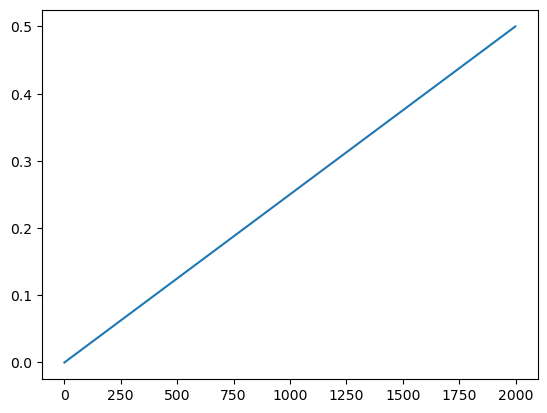

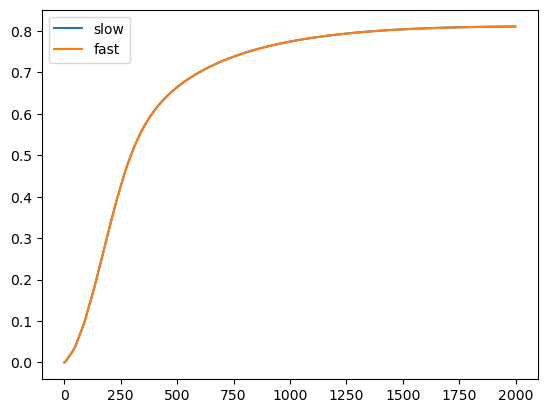

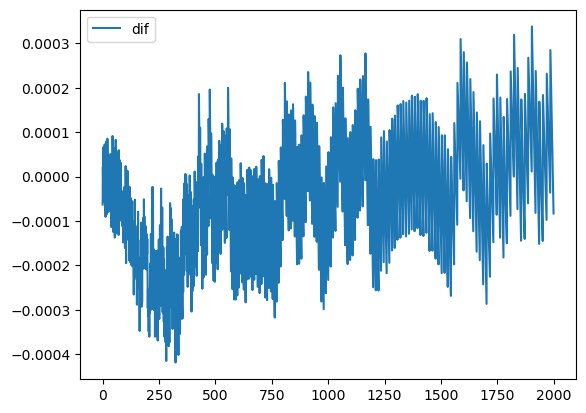

0.0006586297933803833


In [20]:
spac = 0
windows = 2000

plt.figure()
plt.plot(x_train[spac:spac+windows],label='target')
plt.show()

plt.figure()
plt.plot(mags1[spac:spac+windows],label='slow')
plt.plot(magf1[spac:spac+windows],label='fast')
plt.legend()
plt.show()

dif = magf1-mags1
plt.figure()
plt.plot(dif[spac:spac+windows],label='dif')
plt.legend()
plt.show()

print(NRMSE_list(magf1,mags1))

# Error Analysis

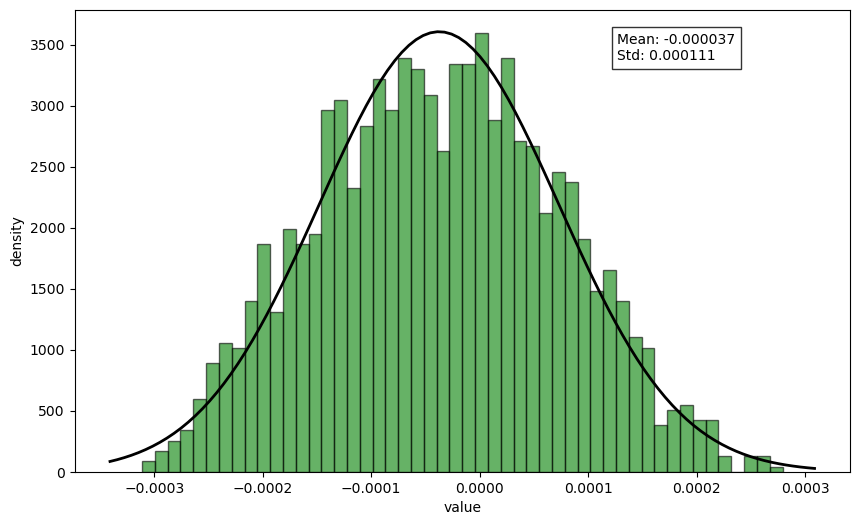

In [32]:
plt.figure(figsize=(10, 6))


count, bins, ignored = plt.hist(dif, bins=50, density=True, alpha=0.6, color='g', edgecolor='k')

mean_dif = np.mean(dif) 
std_dif = np.std(dif) 

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mean_dif, std_dif)
plt.plot(x, p, 'k', linewidth=2)

plt.xlabel('value')
plt.ylabel('density')
plt.text(0.7, 0.95, f'Mean: {mean_dif:.6f}\nStd: {std_dif:.6f}', 
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.8),
         verticalalignment='top')


plt.show()

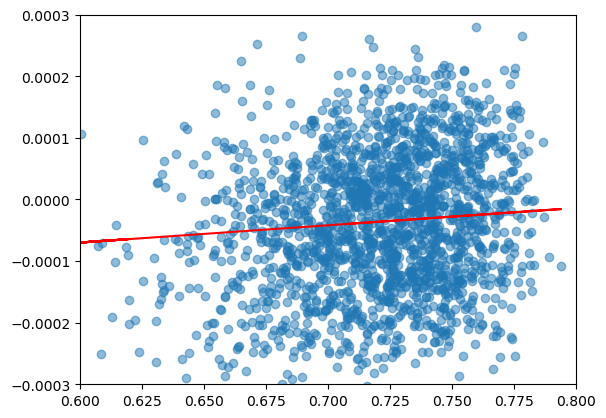

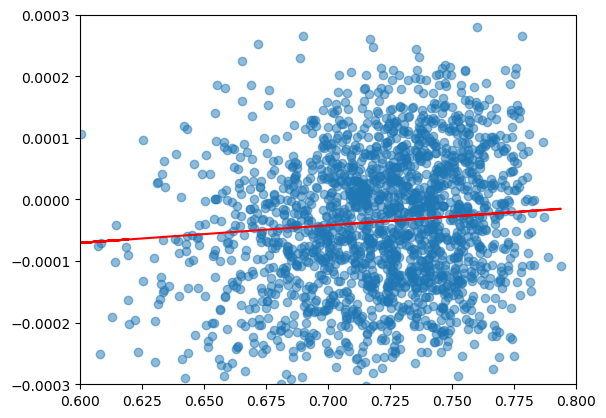

In [36]:
from scipy.stats import linregress

slope, intercept, r_value, p_value, std_err = linregress(mags, dif)
trend_line = slope * mags + intercept

plt.figure()
plt.scatter(mags, dif, alpha=0.5)
plt.plot(mags, trend_line, color='red', label=f"Trend Line (R={r_value:.2f})")
plt.xlim(0.6,0.8)
plt.ylim(-0.0003,0.0003)
plt.show()

slope, intercept, r_value, p_value, std_err = linregress(magf, dif)
trend_line = slope * magf + intercept

plt.figure()
plt.scatter(magf, dif, alpha=0.5)
plt.plot(magf, trend_line, color='red', label=f"Trend Line (R={r_value:.2f})")
plt.xlim(0.6,0.8)
plt.ylim(-0.0003,0.0003)
plt.show()


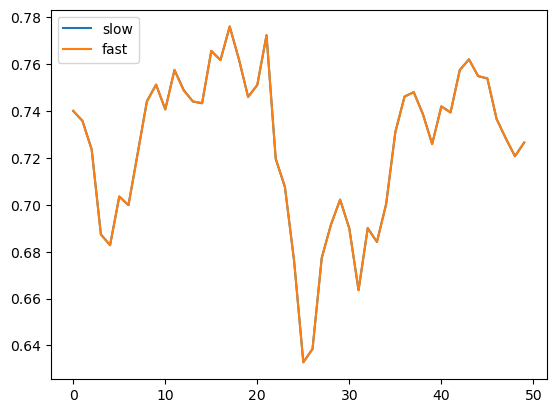

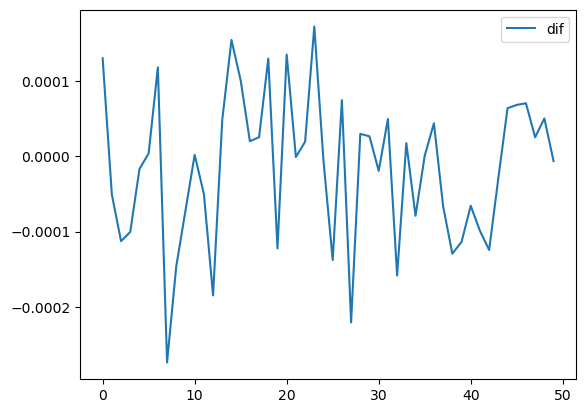

In [53]:
spac = 100
windows = 50

plt.figure()
plt.plot(mags[spac:spac+windows],label='slow')
plt.plot(magf[spac:spac+windows],label='fast')
plt.legend()
plt.show()

dif = magf-mags
plt.figure()
plt.plot(dif[spac:spac+windows],label='dif')
plt.legend()
plt.show()

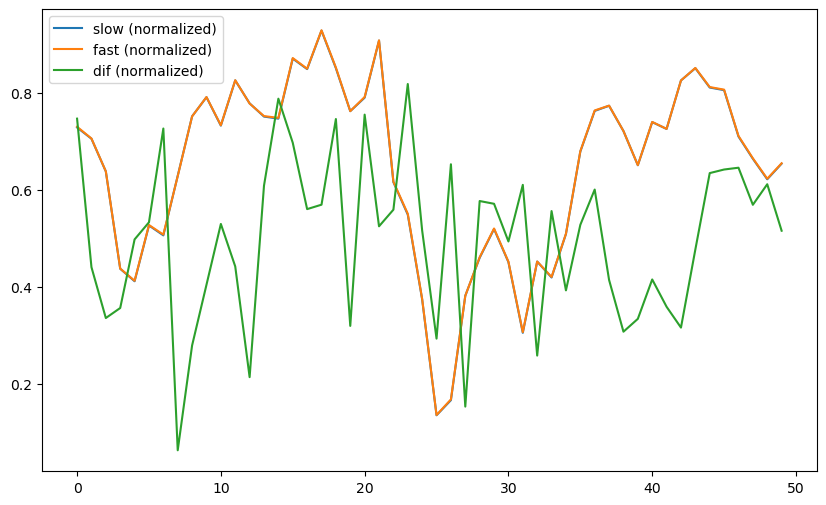

1.518978296992606


In [55]:
mags_norm = (mags[spac:] - mags[spac:].min()) / (mags[spac:].max() - mags[spac:].min())
magf_norm = (magf[spac:] - magf[spac:].min()) / (magf[spac:].max() - magf[spac:].min())
dif_norm = (dif[spac:] - dif[spac:].min()) / (dif[spac:].max() - dif[spac:].min())


plt.figure(figsize=(10, 6))
plt.plot(mags_norm[:windows], label='slow (normalized)')
plt.plot(magf_norm[:windows], label='fast (normalized)')
plt.plot(dif_norm[:windows], label='dif (normalized)')

plt.legend()
plt.show()

nrmse = NRMSE_list(dif_norm,mags_norm)
print(nrmse)

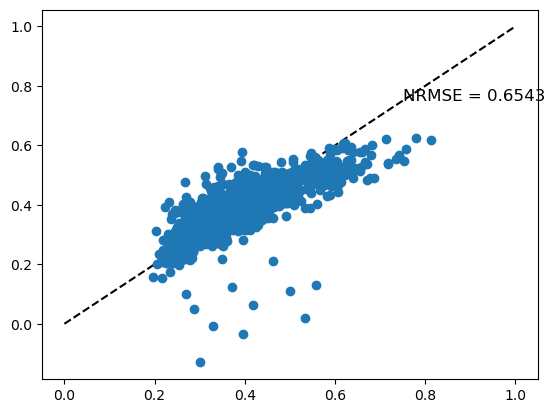

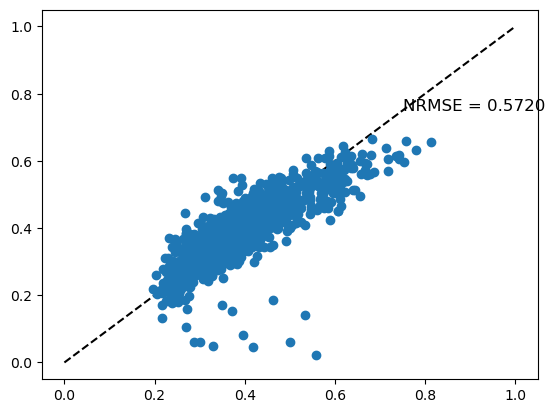

In [88]:
# NARMA10 parameters
Ntrain = 2000
Ntest = 1000
Nwarmup = 0

# Net parameters
Nvirt = 100
m0 = 1e-2
bias = True

# Reservoir parameters
h = 0.4
theta_H = 90
k_s_0 = 0
phi = 45
beta_prime = 10

# Params
params = {
    'theta':1/3, 
    'gamma':.25, 
    'delay_feedback':0, 
    'Nvirt':Nvirt,
    'noise_enable': 'None',
    'noise_seed': 1234,
    'noise_mean':0.0001,
    'noise_std':0.00013,
    'seed_warmup': 1234,
    'length_warmup': Nwarmup,
    'train_sample': Ntrain*Nvirt,
    'test_sample': Ntest*Nvirt,
    'warmup_sample': Nwarmup*Nvirt,
}

spn = spnc_anisotropy(h, theta_H, k_s_0, phi, beta_prime,restart = True,Primep1=None)
transforms = spn.gen_signal_slow_delayed_feedback   
transformf = spn.gen_signal_fast_delayed_feedback

# run
with no_print(): 
    (nrmses_nv1,y_test_nv1,y_s_nv1,y_train_nv1,s_s_nv1,net_s_nv1) = ml.spnc_narma10_weight(Ntrain,Ntest,Nvirt,m0,bias,transforms,params,seed_NARMA=1234,fixed_mask=True,return_all=True, Nwarmup=0)
    (nrmsef_nv1,y_test_nv1,y_f_nv1,y_train_nv1,s_f_nv1,net_f_nv1) = ml.spnc_narma10_weight(Ntrain,Ntest,Nvirt,m0,bias,transformf,params,seed_NARMA=1234,fixed_mask=True,return_all=True, Nwarmup=0)

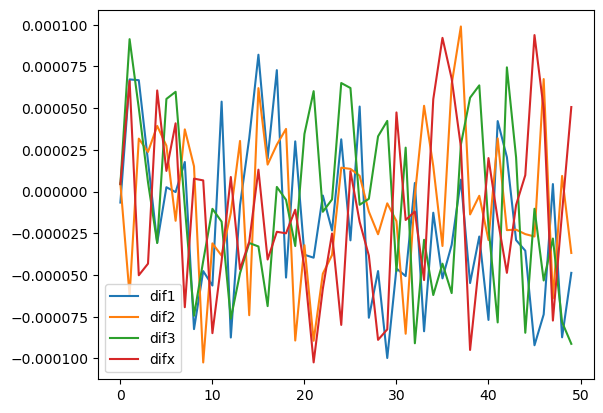

In [91]:
difnv1 = s_f_nv1[:,0]-s_s_nv1[:,0]
difnv2 = s_f_nv1[:,1]-s_s_nv1[:,1]
difnv3 = s_f_nv1[:,2]-s_s_nv1[:,2]
difnvx = s_f_nv1[:,99]-s_s_nv1[:,99]

plt.figure()    
plt.plot(difnv1[:50],label='dif1')
plt.plot(difnv2[:50],label='dif2')
plt.plot(difnv3[:50],label='dif3')
plt.plot(difnvx[:50],label='difx')
plt.legend()
plt.show()



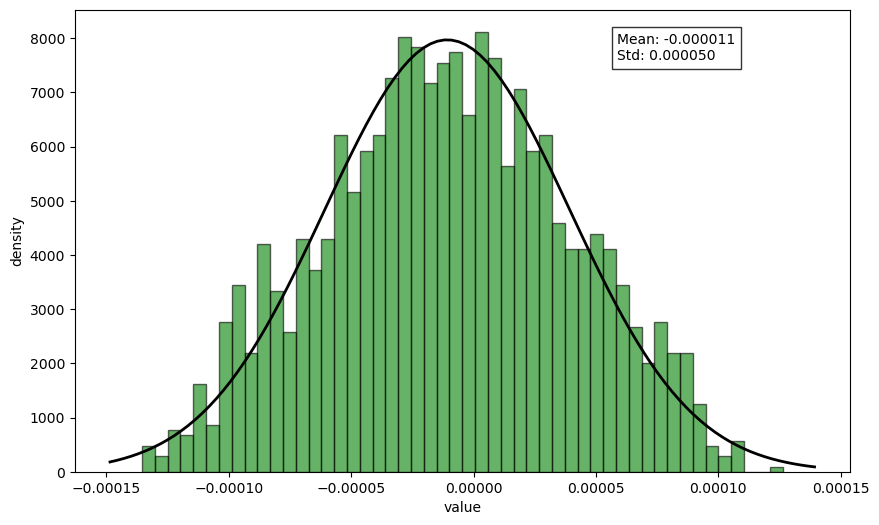

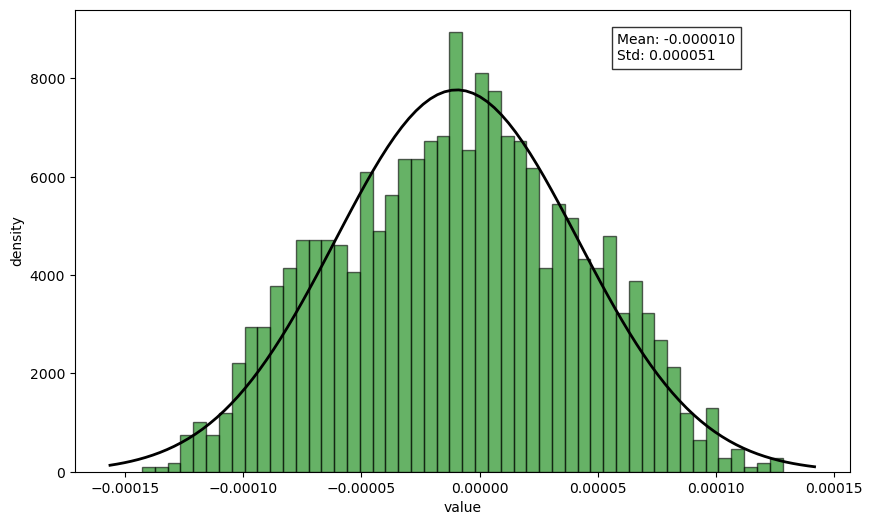

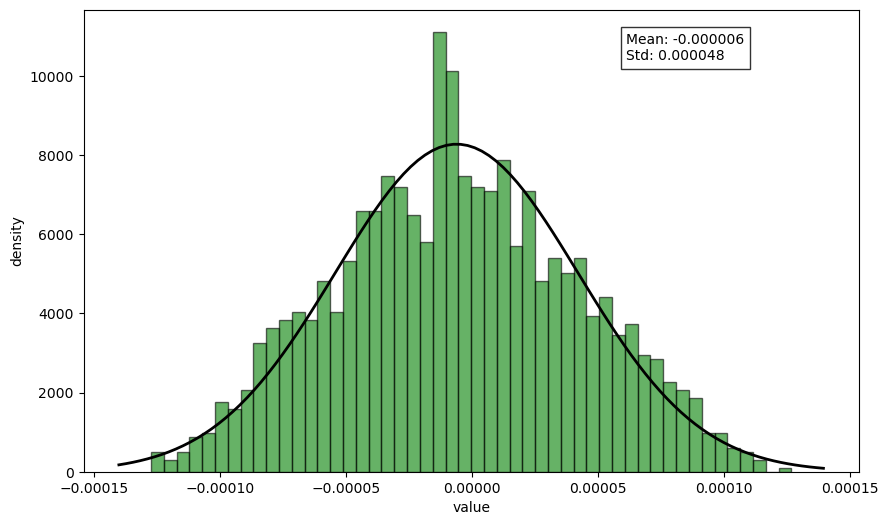

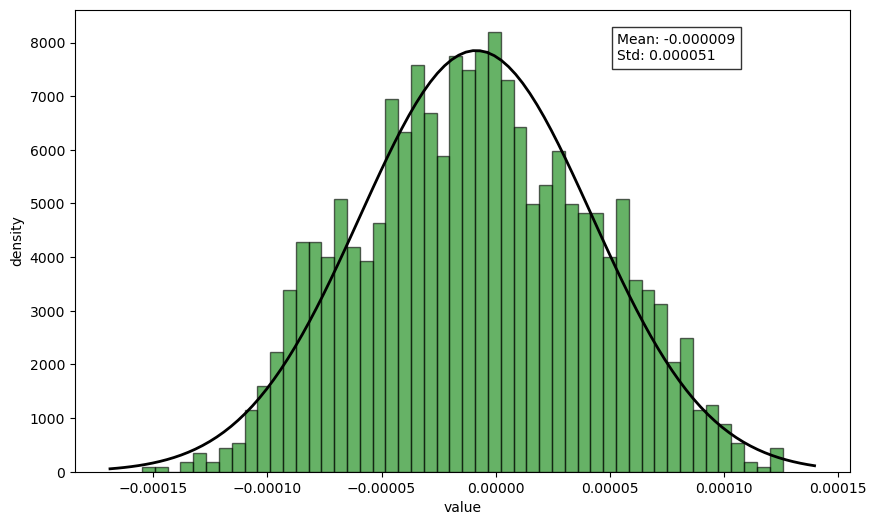

In [92]:
plt.figure(figsize=(10, 6))
count, bins, ignored = plt.hist(difnv1, bins=50, density=True, alpha=0.6, color='g', edgecolor='k')

mean_dif = np.mean(difnv1) 
std_dif = np.std(difnv1) 

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mean_dif, std_dif)
plt.plot(x, p, 'k', linewidth=2)

plt.xlabel('value')
plt.ylabel('density')
plt.text(0.7, 0.95, f'Mean: {mean_dif:.6f}\nStd: {std_dif:.6f}', 
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.8),
         verticalalignment='top')
plt.show()

plt.figure(figsize=(10, 6))
count, bins, ignored = plt.hist(difnv2, bins=50, density=True, alpha=0.6, color='g', edgecolor='k')

mean_dif = np.mean(difnv2) 
std_dif = np.std(difnv2) 

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mean_dif, std_dif)
plt.plot(x, p, 'k', linewidth=2)

plt.xlabel('value')
plt.ylabel('density')
plt.text(0.7, 0.95, f'Mean: {mean_dif:.6f}\nStd: {std_dif:.6f}', 
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.8),
         verticalalignment='top')
plt.show()

plt.figure(figsize=(10, 6))
count, bins, ignored = plt.hist(difnv3, bins=50, density=True, alpha=0.6, color='g', edgecolor='k')

mean_dif = np.mean(difnv3) 
std_dif = np.std(difnv3) 

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mean_dif, std_dif)
plt.plot(x, p, 'k', linewidth=2)

plt.xlabel('value')
plt.ylabel('density')
plt.text(0.7, 0.95, f'Mean: {mean_dif:.6f}\nStd: {std_dif:.6f}', 
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.8),
         verticalalignment='top')
plt.show()

plt.figure(figsize=(10, 6))
count, bins, ignored = plt.hist(difnvx, bins=50, density=True, alpha=0.6, color='g', edgecolor='k')

mean_dif = np.mean(difnvx) 
std_dif = np.std(difnvx) 

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mean_dif, std_dif)
plt.plot(x, p, 'k', linewidth=2)

plt.xlabel('value')
plt.ylabel('density')
plt.text(0.7, 0.95, f'Mean: {mean_dif:.6f}\nStd: {std_dif:.6f}', 
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.8),
         verticalalignment='top')
plt.show()


In [125]:
%matplotlib agg

# NARMA10 parameters
Ntrain = 2000
Ntest = 1000
Nwarmup = 0

Nvirt_list = np.arange(20,400,20)
mean_list = []
std_list = []
mean_error_list = []
std_error_list = []


for i in Nvirt_list:

    Nvirt = i
    # Net parameters
    # Nvirt = 100
    m0 = 1e-2
    bias = True

    # Reservoir parameters
    h = 0.4
    theta_H = 90
    k_s_0 = 0
    phi = 45
    beta_prime = 10

    # Params
    params = {
        'theta':1/3, 
        'gamma':.25, 
        'delay_feedback':0, 
        'Nvirt':Nvirt,
        'noise_enable': 'None',
        'noise_seed': 1234,
        'noise_mean':0.0001,
        'noise_std':0.00013,
        'seed_warmup': 1234,
        'length_warmup': Nwarmup,
        'train_sample': Ntrain*Nvirt,
        'test_sample': Ntest*Nvirt,
        'warmup_sample': Nwarmup*Nvirt,

    }



    spn = spnc_anisotropy(h, theta_H, k_s_0, phi, beta_prime,restart = True,Primep1=None)
    transforms = spn.gen_signal_slow_delayed_feedback   
    transformf = spn.gen_signal_fast_delayed_feedback

    # run
    with no_print(): 
        (nrmses_nv1,y_test_nv1,y_s_nv1,y_train_nv1,s_s_nv1,net_s_nv1) = ml.spnc_narma10_weight(Ntrain,Ntest,Nvirt,m0,bias,transforms,params,seed_NARMA=1234,fixed_mask=True,return_all=True, Nwarmup=0)
        (nrmsef_nv1,y_test_nv1,y_f_nv1,y_train_nv1,s_f_nv1,net_f_nv1) = ml.spnc_narma10_weight(Ntrain,Ntest,Nvirt,m0,bias,transformf,params,seed_NARMA=1234,fixed_mask=True,return_all=True, Nwarmup=0)

    n_column = s_f_nv1.shape[1]
    np.random.seed(1234)
    if n_column <= 10:
        random_column = range(n_column)
    else:
        random_column = np.random.choice(n_column, 10, replace=False)
    
    mean_mean = []
    mean_std = []


    for col in random_column:
        dif = s_f_nv1[:,col]-s_s_nv1[:,col]
      
        mean_dif = np.mean(dif) 
        std_dif = np.std(dif)

        mean_mean.append(mean_dif)
        mean_std.append(std_dif)

    mean_dif = np.mean(mean_mean)
    mean_error = np.std(mean_mean)/np.sqrt(len(mean_mean))  
    std_dif = np.mean(mean_std)
    std_error = np.std(mean_std)/np.sqrt(len(mean_std))

    mean_list.append(mean_dif)
    std_list.append(std_dif)
    mean_error_list.append(mean_error)
    std_error_list.append(std_error)  


plt.figure()
plt.scatter(Nvirt_list,mean_list,label='mean')
plt.scatter(Nvirt_list,std_list,label='std')
plt.legend()
plt.show()



    

    

c:\Users\Chen\Desktop\Repository\spnc\spnc_ml.py:573: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()
c:\Users\Chen\Desktop\Repository\spnc\spnc_ml.py:573: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()
c:\Users\Chen\Desktop\Repository\spnc\spnc_ml.py:573: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()
c:\Users\Chen\Desktop\Repository\spnc\spnc_ml.py:573: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()
c:\Users\Chen\Desktop\Repository\spnc\spnc_ml.py:573: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()
c:\Users\Chen\Desktop\Repository\spnc\spnc_ml.py:573: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the f

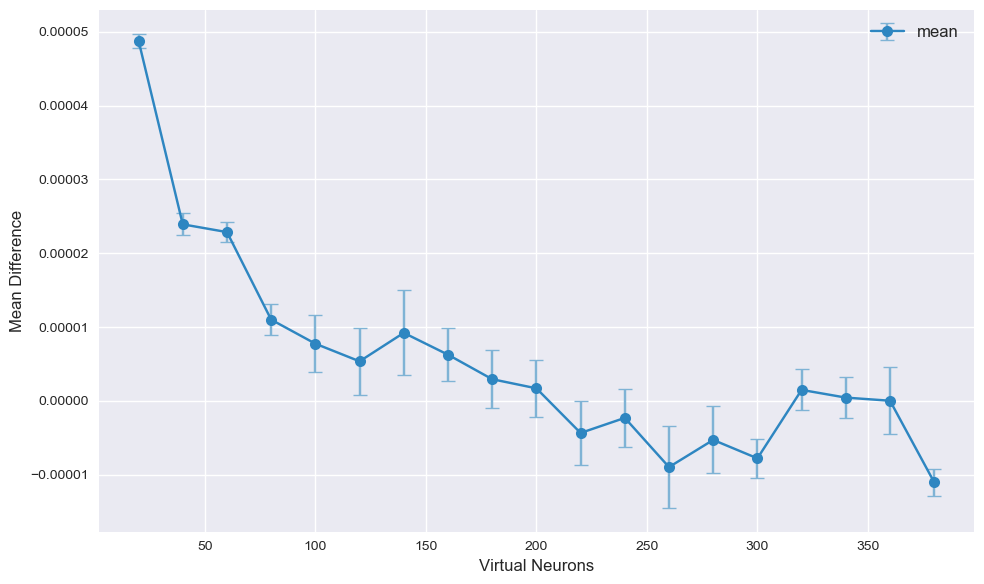

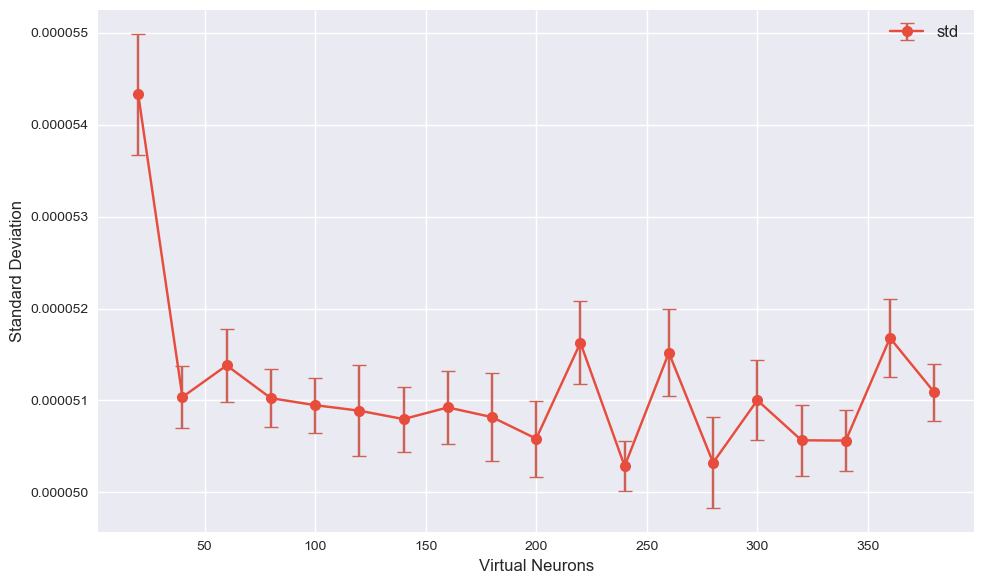

[ 4.88003267e-05  2.39171505e-05  2.28644979e-05  1.10022562e-05
  7.74586382e-06  5.35681857e-06  9.21583914e-06  6.25644835e-06
  2.93499669e-06  1.69699068e-06 -4.34962194e-06 -2.30663974e-06
 -8.97141649e-06 -5.29259272e-06 -7.78871329e-06  1.48572687e-06
  4.42161069e-07  1.79511980e-08 -1.10353135e-05]


In [134]:
%matplotlib inline
import matplotlib.pyplot as plt
# plt.style.use('seaborn')  # 使用seaborn样式

# 设置全局字体大小
plt.rcParams.update({'font.size': 12})

# 第一个图 - 均值
plt.figure(figsize=(10, 6))
plt.errorbar(Nvirt_list, mean_list, 
            yerr=mean_error_list,
            fmt='o-',  # 点和线的组合
            color='#2E86C1',  # 深蓝色
            ecolor='#7FB3D5',  # 浅蓝色误差线
            capsize=5,  # 误差线端点大小
            capthick=1,  # 误差线端点粗细
            markersize=8,  # 点的大小
            label='mean')

# plt.grid(True, linestyle='--', alpha=0.7)
plt.xlabel('Virtual Neurons', fontsize=12)
plt.ylabel('Mean Difference', fontsize=12)
# plt.title('Mean Difference vs Virtual Neurons', fontsize=14, pad=15)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# 第二个图 - 标准差
plt.figure(figsize=(10, 6))
plt.errorbar(Nvirt_list, std_list, 
            yerr=std_error_list,
            fmt='o-',
            color='#E74C3C',  # 红色
            ecolor='#CD6155',  # 浅红色误差线
            capsize=5,
            capthick=1,
            markersize=8,
            label='std')

# plt.grid(True, linestyle='--', alpha=0.7)
plt.xlabel('Virtual Neurons', fontsize=12)
plt.ylabel('Standard Deviation', fontsize=12)
# plt.title('Standard Deviation vs Virtual Neurons', fontsize=14, pad=15)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# save data as npy.file
# set address
address = 'results/'
Path(address).mkdir(parents=True, exist_ok=True)

np.save(address + 'mean_list.npy', mean_list)
np.save(address + 'std_list.npy', std_list)
np.save(address + 'mean_error_list.npy', mean_error_list)
np.save(address + 'std_error_list.npy', std_error_list)




# Parameter change during the Ridge Regression

In [2]:
# NARMA10 parameters
Ntrain = 2000
Ntest = 1000
Nwarmup = 0

# Net parameters
Nvirt = 400
m0 = 0.003
bias = True

# Reservoir parameters
h = 0.4
theta_H = 90
k_s_0 = 0
phi = 45
beta_prime = 20

# Params
params = {
    'theta':0.3, 
    'gamma':.113, 
    'delay_feedback':0, 
    'Nvirt':Nvirt,
    'noise_enable': 'None',
    'noise_seed': 1234,
    'noise_mean':0.0001,
    'noise_std':0.00013,
    'seed_warmup': 1234,
    'length_warmup': Nwarmup,
    'train_sample': Ntrain*Nvirt,
    'test_sample': Ntest*Nvirt,
    'warmup_sample': Nwarmup*Nvirt,
}

spn = spnc_anisotropy(h, theta_H, k_s_0, phi, beta_prime,restart = True,Primep1=None)
#transforms = spn.gen_signal_slow_delayed_feedback   
transformf = spn.gen_signal_fast_delayed_feedback

# run
#(nrmses,y_test,y_s,y_train,s_s,net_s) = ml.spnc_narma10_weight(Ntrain,Ntest,Nvirt,m0,bias,transforms,params,seed_NARMA=1234,fixed_mask=True,return_all=True, Nwarmup=0)
(nrmsef,y_test,y_f,y_train,s_f,net_f) = ml.spnc_narma10_weight(Ntrain,Ntest,Nvirt,m0,bias,transformf,params,seed_NARMA=1234,fixed_mask=True,return_all=True, Nwarmup=0)

seed warmup: 1234
length warmup: 0
seed NARMA: 1234
Nwarmup: 0
Samples for training:  2000
Samples for test:  1000
Nin = 1 , Nout =  2000 , Nvirt =  400
Deterministic mask will be used
1234
current phase: warmup
p1 in warmup & fast: 0.49999977789842975
current phase: train
p1 in train & fast: 0.49999977789842975
noise-free training output


KeyboardInterrupt: 

In [2]:
# NARMA10 parameters
Ntrain = 2000
Ntest = 1000
Nwarmup = 0

# Net parameters
Nvirt = 400
m0 = 0.003
bias = True

# Reservoir parameters
h = 0.4
theta_H = 90
k_s_0 = 0
phi = 45
beta_prime = 20

# Params
params = {
    'theta':0.3, 
    'gamma':.113, 
    'delay_feedback':0, 
    'Nvirt':Nvirt,
    'noise_enable': 'None',
    'noise_seed': 1234,
    'noise_mean':0.0001,
    'noise_std':0.00013,
    'seed_warmup': 1234,
    'length_warmup': Nwarmup,
    'train_sample': Ntrain*Nvirt,
    'test_sample': Ntest*Nvirt,
    'warmup_sample': Nwarmup*Nvirt,
}

spn = spnc_anisotropy(h, theta_H, k_s_0, phi, beta_prime,restart = True,Primep1=None)
transforms = spn.gen_signal_slow_delayed_feedback   
# transformf = spn.gen_signal_fast_delayed_feedback

# run
(nrmses,y_test,y_s,y_train,s_s,net_s) = ml.spnc_narma10_weight(Ntrain,Ntest,Nvirt,m0,bias,transforms,params,seed_NARMA=1234,fixed_mask=True,return_all=True, Nwarmup=0)
# (nrmsef,y_test,y_f,y_train,s_f,net_f) = ml.spnc_narma10_weight(Ntrain,Ntest,Nvirt,m0,bias,transformf,params,seed_NARMA=1234,fixed_mask=True,return_all=True, Nwarmup=0)

seed warmup: 1234
length warmup: 0
seed NARMA: 1234
Nwarmup: 0
Samples for training:  2000
Samples for test:  1000
Nin = 1 , Nout =  2000 , Nvirt =  400
Deterministic mask will be used
1234
current phase: warmup
p1 in warmup & slow: 0.49999977789842975
current phase: train
p1 in train & slow: 0.49999977789842975
noise_seed: 1234
noise_mean_train: 0.0001
noise-free training output


KeyboardInterrupt: 

In [9]:
abc = NRMSE_list(y_test[100:], y_f[100:])
bac = NRMSE_list(y_test[100:], y_s[100:])
print(abc)
print(bac)

0.4958898593836039
0.5727164602043431


seed warmup: 1234
length warmup: 0
seed NARMA: 1234
Nwarmup: 0
Samples for training:  2000
Samples for test:  1000
Nin = 1 , Nout =  2000 , Nvirt =  40
Deterministic mask will be used
1234
current phase: warmup
p1 in warmup & slow: 0.4999998889492148
current phase: train
p1 in train & slow: 0.4999998889492148
noise_seed: 1234
noise_mean_train: 0.0001
noise-free training output
restarted
Training data size:  80000
Training data shape:  (2000, 40)
Seed Training: 1234
error with zero =  0.004380562850294669
l= 4.5399929762484854e-05 0.004456481437081064
lambda=4.5399929762484854e-05: MSE=0.004456481437081064
Current weights: [[  7.60437401]
 [  5.8876537 ]
 [ -1.04108387]
 [-16.90186923]
 [-21.76650928]
 [-21.06486875]
 [-25.81491046]
 [-37.35104418]
 [-20.96158947]
 [-16.27331111]
 [ -6.75195342]
 [ -3.57510736]
 [-18.38793318]
 [-12.24282477]
 [-18.36978005]
 [  3.57521584]
 [  3.67813362]
 [  9.84360425]
 [  3.66461435]
 [  8.00757195]
 [ -3.94882413]
 [ 15.23125359]
 [ 27.0735769 ]
 [

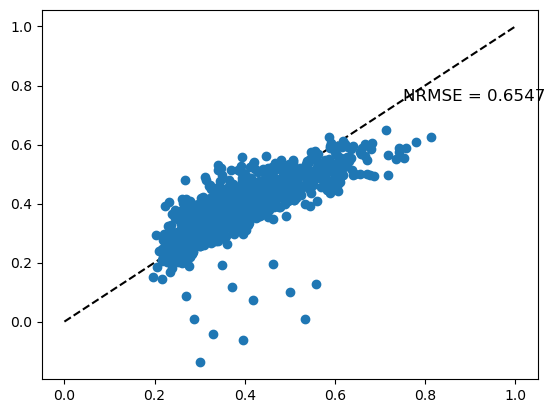

seed warmup: 1234
length warmup: 0
seed NARMA: 1234
Nwarmup: 0
Samples for training:  2000
Samples for test:  1000
Nin = 1 , Nout =  2000 , Nvirt =  40
Deterministic mask will be used
1234
current phase: warmup
p1 in warmup & fast: 0.4999998889492148
current phase: train
p1 in train & fast: 0.4999998889492148
noise-free training output
restarted
Training data size:  80000
Training data shape:  (2000, 40)
Seed Training: 1234
error with zero =  0.0033847981091504574
l= 4.5399929762484854e-05 0.004384336979609115
lambda=4.5399929762484854e-05: MSE=0.004384336979609115
Current weights: [[ 7.47991004e+00]
 [ 8.27565224e+00]
 [-3.06756574e-01]
 [-1.21994233e+01]
 [-2.13063731e+01]
 [-2.56746877e+01]
 [-2.55483963e+01]
 [-3.79817057e+01]
 [-2.32792837e+01]
 [-1.36198407e+01]
 [-8.84363084e+00]
 [-5.26589997e+00]
 [-1.71737374e+01]
 [-1.90104753e+01]
 [-1.68070746e+01]
 [-8.61817048e-03]
 [ 5.22930017e+00]
 [ 5.47756773e+00]
 [ 6.79356102e+00]
 [ 1.08497464e+01]
 [ 1.29891020e+00]
 [ 1.7819400

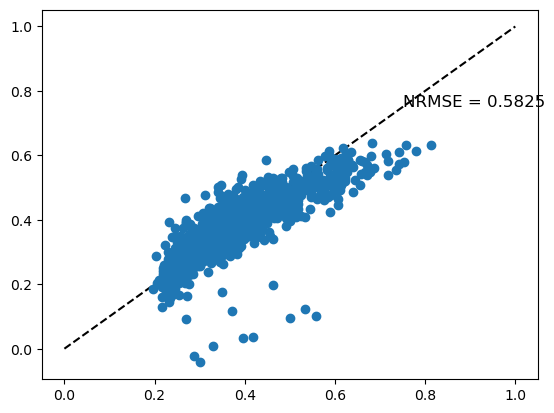

In [4]:
# NARMA10 parameters
Ntrain = 2000
Ntest = 1000
Nwarmup = 0

# Net parameters
Nvirt = 40
m0 = 1e-2
bias = True

# Reservoir parameters
h = 0.4
theta_H = 90
k_s_0 = 0
phi = 45
beta_prime = 10

# Params
params = {
    'theta':1/3, 
    'gamma':.25, 
    'delay_feedback':0, 
    'Nvirt':Nvirt,
    'noise_enable': 'None',
    'noise_seed': 1234,
    'noise_mean':0.0001,
    'noise_std':0.00013,
    'seed_warmup': 1234,
    'length_warmup': Nwarmup,
    'train_sample': Ntrain*Nvirt,
    'test_sample': Ntest*Nvirt,
    'warmup_sample': Nwarmup*Nvirt,
}

spn = spnc_anisotropy(h, theta_H, k_s_0, phi, beta_prime,restart = True,Primep1=None)
transforms = spn.gen_signal_slow_delayed_feedback   
transformf = spn.gen_signal_fast_delayed_feedback

# run
(nrmsesr,y_testr,y_sr,y_trainr,s_sr,net_sr,x_trainsr,s_trainsr,x_testsr,s_testsr) = ml.spnc_narma10_weight(Ntrain,Ntest,Nvirt,m0,bias,transforms,params,seed_NARMA=1234,fixed_mask=True,return_all=True, Nwarmup=0)
(nrmsefr,y_testr,y_fr,y_trainr,s_fr,net_fr,x_trainfr,s_trainfr,x_testfr,S_testfr) = ml.spnc_narma10_weight(Ntrain,Ntest,Nvirt,m0,bias,transformf,params,seed_NARMA=1234,fixed_mask=True,return_all=True, Nwarmup=0)

seed warmup: 1234
length warmup: 0
seed NARMA: 1234
Nwarmup: 0
Samples for training:  2000
Samples for test:  1000
Nin = 1 , Nout =  2000 , Nvirt =  40
Deterministic mask will be used
1234
current phase: warmup
p1 in warmup & slow: 0.4999998889492148
current phase: train
p1 in train & slow: 0.4999998889492148
noise_seed: 1234
noise_mean_train: 0.0001
noise-free training output
skip restarting..
Training data size:  80000
Training data shape:  (2000, 40)
Seed Training: 1234
error with zero =  0.004380562850294669
l= 4.5399929762484854e-05 0.004456481437081064
lambda=4.5399929762484854e-05: MSE=0.004456481437081064
Current weights: [[  7.60437401]
 [  5.8876537 ]
 [ -1.04108387]
 [-16.90186923]
 [-21.76650928]
 [-21.06486875]
 [-25.81491046]
 [-37.35104418]
 [-20.96158947]
 [-16.27331111]
 [ -6.75195342]
 [ -3.57510736]
 [-18.38793318]
 [-12.24282477]
 [-18.36978005]
 [  3.57521584]
 [  3.67813362]
 [  9.84360425]
 [  3.66461435]
 [  8.00757195]
 [ -3.94882413]
 [ 15.23125359]
 [ 27.0735

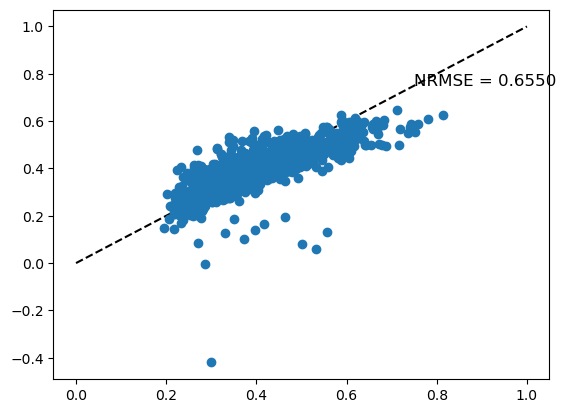

seed warmup: 1234
length warmup: 0
seed NARMA: 1234
Nwarmup: 0
Samples for training:  2000
Samples for test:  1000
Nin = 1 , Nout =  2000 , Nvirt =  40
Deterministic mask will be used
1234
current phase: warmup
p1 in warmup & fast: 0.4999998889492148
current phase: train
p1 in train & fast: 0.4999998889492148
noise-free training output
skip restarting..
Training data size:  80000
Training data shape:  (2000, 40)
Seed Training: 1234
error with zero =  0.0033847981091504574
l= 4.5399929762484854e-05 0.004384336979609115
lambda=4.5399929762484854e-05: MSE=0.004384336979609115
Current weights: [[ 7.47991004e+00]
 [ 8.27565224e+00]
 [-3.06756574e-01]
 [-1.21994233e+01]
 [-2.13063731e+01]
 [-2.56746877e+01]
 [-2.55483963e+01]
 [-3.79817057e+01]
 [-2.32792837e+01]
 [-1.36198407e+01]
 [-8.84363084e+00]
 [-5.26589997e+00]
 [-1.71737374e+01]
 [-1.90104753e+01]
 [-1.68070746e+01]
 [-8.61817048e-03]
 [ 5.22930017e+00]
 [ 5.47756773e+00]
 [ 6.79356102e+00]
 [ 1.08497464e+01]
 [ 1.29891020e+00]
 [ 1

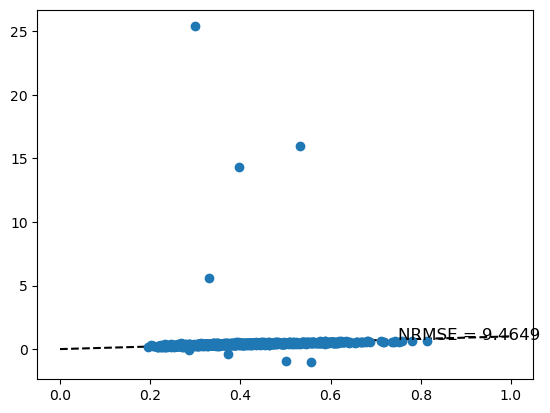

In [5]:
# NARMA10 parameters
Ntrain = 2000
Ntest = 1000
Nwarmup = 0

# Net parameters
Nvirt = 40
m0 = 1e-2
bias = True

# Reservoir parameters
h = 0.4
theta_H = 90
k_s_0 = 0
phi = 45
beta_prime = 10

# Params
params = {
    'theta':1/3, 
    'gamma':.25, 
    'delay_feedback':0, 
    'Nvirt':Nvirt,
    'noise_enable': 'None',
    'noise_seed': 1234,
    'noise_mean':0.0001,
    'noise_std':0.00013,
    'seed_warmup': 1234,
    'length_warmup': Nwarmup,
    'train_sample': Ntrain*Nvirt,
    'test_sample': Ntest*Nvirt,
    'warmup_sample': Nwarmup*Nvirt,
}

spns = spnc_anisotropy(h, theta_H, k_s_0, phi, beta_prime,restart = False,Primep1=None)
spnf = spnc_anisotropy(h, theta_H, k_s_0, phi, beta_prime,restart = False,Primep1=None)
transforms = spns.gen_signal_slow_delayed_feedback   
transformf = spnf.gen_signal_fast_delayed_feedback

# run
(nrmses,y_test,y_s,y_train,s_s,net_s,x_trains,s_trains,x_tests,s_tests) = ml.spnc_narma10_weight(Ntrain,Ntest,Nvirt,m0,bias,transforms,params,seed_NARMA=1234,fixed_mask=True,return_all=True, Nwarmup=0)
(nrmsef,y_test,y_f,y_train,s_f,net_f,x_trainf,s_trainf,x_testf,s_testf) = ml.spnc_narma10_weight(Ntrain,Ntest,Nvirt,m0,bias,transformf,params,seed_NARMA=1234,fixed_mask=True,return_all=True, Nwarmup=0)

add some noise to see whether the error_zero change

seed warmup: 1234
length warmup: 0
seed NARMA: 1234
Nwarmup: 0
Samples for training:  2000
Samples for test:  1000
Nin = 1 , Nout =  2000 , Nvirt =  40
Deterministic mask will be used
1234
current phase: warmup
p1 in warmup & slow: 0.4999998889492148
current phase: train
p1 in train & slow: 0.4999998889492148
noise_seed: 1234
noise_mean_train: 3e-06
noisy training output
restarted
Training data size:  80000
Training data shape:  (2000, 40)
Seed Training: 1234
error with zero =  0.005530044550859953
l= 4.5399929762484854e-05 0.00676688266170747
lambda=4.5399929762484854e-05: MSE=0.00676688266170747
Current weights: [[  9.51715481]
 [ 11.07570324]
 [  5.11775728]
 [-16.01120819]
 [-23.11005767]
 [-30.41022462]
 [-35.67642863]
 [-12.01872288]
 [  5.91938988]
 [  4.62066171]
 [  7.91776227]
 [ -8.88857711]
 [ -7.29547264]
 [ 13.37946027]
 [ 33.63990948]
 [ 46.58001429]
 [ 34.96623936]
 [ 21.65301487]
 [  7.55186231]
 [  1.97522118]
 [ 16.68896184]
 [ 28.1066061 ]
 [ 18.42584667]
 [ 24.3449

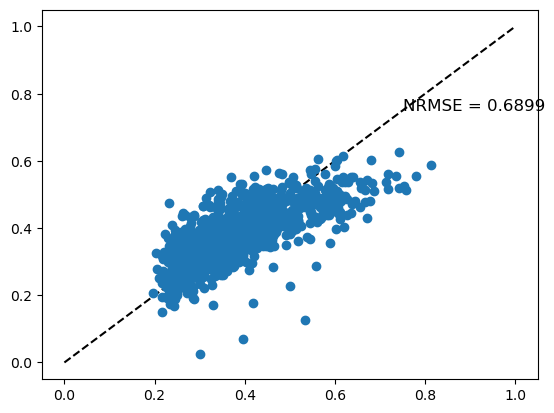

In [6]:
# NARMA10 parameters
Ntrain = 2000
Ntest = 1000
Nwarmup = 0

# Net parameters
Nvirt = 40
m0 = 1e-2
bias = True

# Reservoir parameters
h = 0.4
theta_H = 90
k_s_0 = 0
phi = 45
beta_prime = 10

# Params
params = {
    'theta':1/3, 
    'gamma':.25, 
    'delay_feedback':0, 
    'Nvirt':Nvirt,
    'noise_seed': 1234,
    'noise_train': True,
    'noise_mean_train':0.000003,
    'noise_std_train':0.000005,
    'noise_test': True,
    'noise_mean_test':0.000003,    
    'noise_std_test':0.000005,
    'seed_warmup': 1234,
    'length_warmup': Nwarmup,
    'train_sample': Ntrain*Nvirt,
    'test_sample': Ntest*Nvirt,
    'warmup_sample': Nwarmup*Nvirt,
    'value':[-0.000004,0.000006],
    'prob':[1/3,2/3]
}
spn = spnc_anisotropy(h, theta_H, k_s_0, phi, beta_prime,restart = True,Primep1=None)
transformn = spn.gen_signal_slow_delayed_feedback   

# run
(nrmsen,y_test,y_n,y_train,s_n,net_n,x_trainn,s_trainn,x_testn,s_testn) = ml.spnc_narma10_weight(Ntrain,Ntest,Nvirt,m0,bias,transformn,params,seed_NARMA=1234,fixed_mask=True,return_all=True, Nwarmup=0)


首先调查x_train

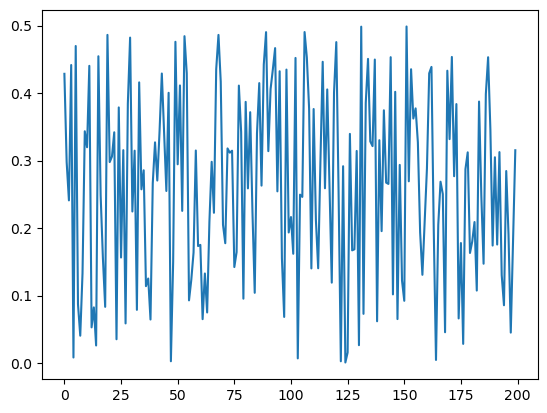

(2000, 1)


In [10]:
spac = 0
windows = 200
plt.figure()
plt.plot(x_trainsr[spac:spac+windows])
plt.show()

print(np.shape(x_trainsr))


第二个：s_train (feature matrix)

(2000, 40)
(2000, 40)


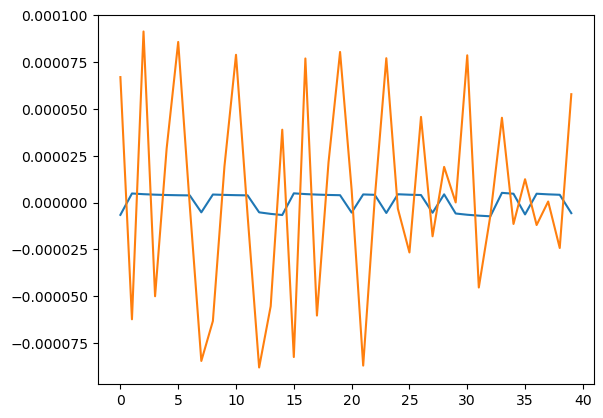

Frobenius Norm of Difference: 0.016411260448757507
------------------------------------
Mean Difference: 2.5708510624256015e-05
Standard Deviation of Difference: 5.2016255636526004e-05
Max Difference: 0.00018449795078201436
Min Difference: -0.00013299010542611178
------------------------------------


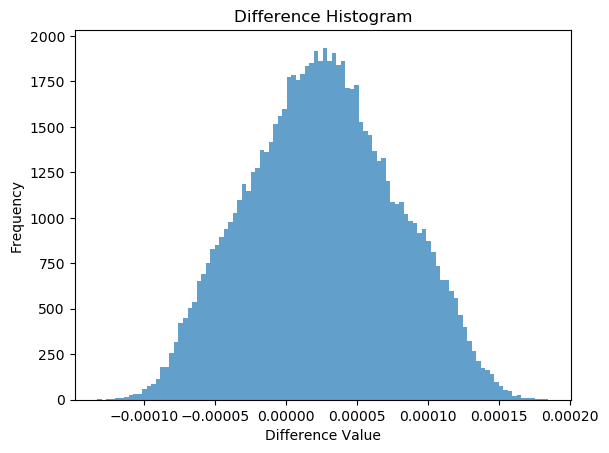

------------------------------------
Mean Pearson Correlation: 0.9997223693438506
Mean Spearman Correlation: 0.9996918471979617
------------------------------------


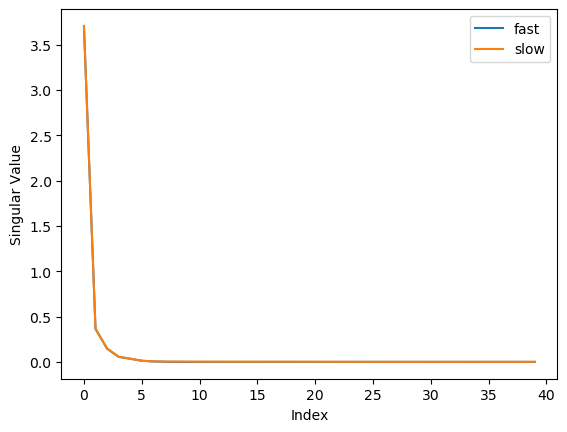

Cosine Similarity of Principal Directions: [ 0.99999952  0.99998015  0.99983869 -0.99895379 -0.99767641 -0.98111743
 -0.913962    0.00937672  0.00992038 -0.05631158  0.0686019   0.00623921
  0.00367186 -0.03252286 -0.00603116 -0.04698573  0.03114436 -0.11370189
  0.04037264 -0.01627904  0.01670967  0.00891166  0.00784327  0.03331573
  0.00548279 -0.03877671  0.04636327  0.00389885 -0.0853349  -0.02020546
 -0.00620339  0.00716715  0.00316547  0.00741691  0.02110554 -0.01686209
  0.05354664  0.01529671 -0.01702086  0.00368131]
Condition Number (fast): 13627542.953458048
Condition Number (slow): 3199.3513054262976
Effective Rank (fast): 4
Effective Rank (slow): 4
------------------------------------
Projection Error: 0.007847814139359343
------------------------------------


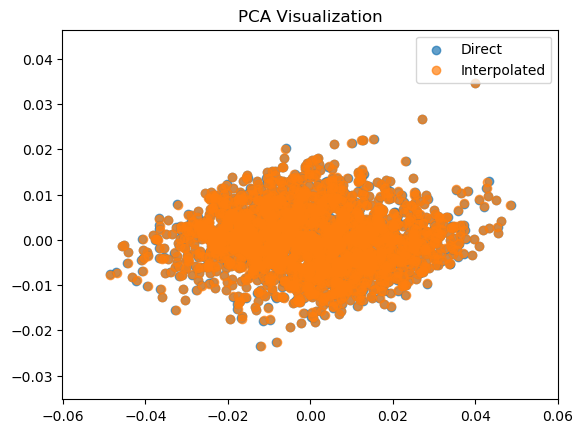

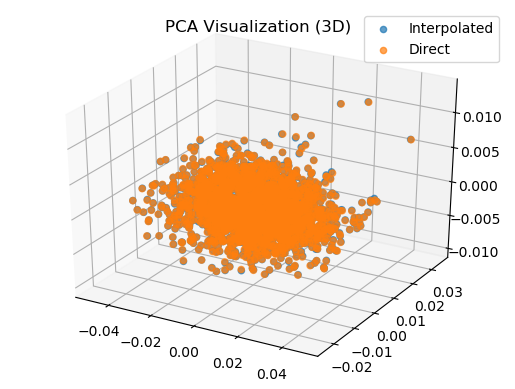

Wasserstein Distances for each PCA component:
Component 1: 4.4231490925887755e-05
Component 2: 2.424076857778804e-05
Component 3: 1.5658672477320287e-05
Component 4: 9.042202528128036e-06
Component 5: 7.847494726310097e-06
Component 6: 5.959190099829936e-06
Component 7: 9.428751869770547e-06
Component 8: 4.929367104575258e-05
Component 9: 6.69297196349011e-05
Component 10: 5.824966098505862e-05
Component 11: 5.5388922266381136e-05
Component 12: 5.1411730879969196e-05
Component 13: 5.0460907245344146e-05
Component 14: 4.974482991705591e-05
Component 15: 4.713856401645909e-05
Component 16: 4.553645050848253e-05
Component 17: 4.262816317327044e-05
Component 18: 4.154257450145337e-05
Component 19: 4.143595464706547e-05
Component 20: 4.01331469452196e-05
Component 21: 3.79850684402306e-05
Component 22: 3.3612844578142465e-05
Component 23: 3.371958442609885e-05
Component 24: 3.318195622199585e-05
Component 25: 3.14098569804557e-05
Component 26: 3.083569501266683e-05
Component 27: 2.985902572

In [39]:

from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr, spearmanr,wasserstein_distance


print(np.shape(s_trainsr))
print(np.shape(s_trainfr))

# 1. Compute Difference Matrix
delta_X = s_trainfr - s_trainsr

plt.figure()
plt.plot(delta_X[0,:])
plt.plot(delta_X[1,:])
plt.show()

# 2. Element-wise metrics
abs_diff = np.abs(delta_X)
square_diff = delta_X ** 2
frobenius_norm = np.linalg.norm(delta_X, ord='fro')
rel_diff = abs_diff / (np.abs(s_trainsr) + 1e-12)  # Avoid division by zero

print("Frobenius Norm of Difference:", frobenius_norm)
print('------------------------------------')

# 3. Statistical Analysis
mean_diff = np.mean(delta_X)
std_diff = np.std(delta_X)
max_diff = np.max(delta_X)
min_diff = np.min(delta_X)

print("Mean Difference:", mean_diff)
print("Standard Deviation of Difference:", std_diff)
print("Max Difference:", max_diff)
print("Min Difference:", min_diff)
print('------------------------------------')

# Histogram
plt.hist(delta_X.flatten(), bins=100, alpha=0.7)
plt.title("Difference Histogram")
plt.xlabel("Difference Value")
plt.ylabel("Frequency")
plt.show()
print('------------------------------------')

# 4. Correlation Analysis
pearson_corr = [pearsonr(s_trainfr[:, i], s_trainsr[:, i])[0] for i in range(s_trainfr.shape[1])]
spearman_corr = [spearmanr(s_trainfr[:, i], s_trainsr[:, i])[0] for i in range(s_trainfr.shape[1])]

print("Mean Pearson Correlation:", np.mean(pearson_corr))
print("Mean Spearman Correlation:", np.mean(spearman_corr))
print('------------------------------------')

# 5. Singular Value Decomposition (SVD)
U_interp, S_interp, Vt_interp = np.linalg.svd(s_trainfr, full_matrices=False)
U_direct, S_direct, Vt_direct = np.linalg.svd(s_trainsr, full_matrices=False)

# Compare Singular Values
plt.plot(S_interp, label="fast")
plt.plot(S_direct, label="slow")

plt.xlabel("Index")
plt.ylabel("Singular Value")
plt.legend()
plt.show()

# 5.0 Compare Principal Directions (Cosine Similarity)
cosine_similarity = np.sum(U_interp * U_direct, axis=0) / (
    np.linalg.norm(U_interp, axis=0) * np.linalg.norm(U_direct, axis=0)
)

print("Cosine Similarity of Principal Directions:", cosine_similarity)

# 5.1 Condition Numbers
cond_interp = S_interp[0] / S_interp[-1] if S_interp[-1] > 1e-12 else np.inf
cond_direct = S_direct[0] / S_direct[-1] if S_direct[-1] > 1e-12 else np.inf

print("Condition Number (fast):", cond_interp)
print("Condition Number (slow):", cond_direct)

# 5.2 Effective Rank
def effective_rank(singular_values, threshold=0.01):
    normalized_singular_values = singular_values / np.sum(singular_values)
    return np.sum(normalized_singular_values > threshold)

effective_rank_interp = effective_rank(S_interp)
effective_rank_direct = effective_rank(S_direct)

print("Effective Rank (fast):", effective_rank_interp)
print("Effective Rank (slow):", effective_rank_direct)
print('------------------------------------')

# 6. Projection Error
P_direct = s_trainfr @ np.linalg.pinv(s_trainsr)
R = s_trainfr - P_direct @ s_trainfr
projection_error = np.linalg.norm(R, ord='fro')
print("Projection Error:", projection_error)
print('------------------------------------')

# 7. Dimensionality Reduction and Visualization
pca = PCA(n_components=2)
X_interp_pca = pca.fit_transform(s_trainfr)
X_direct_pca = pca.fit_transform(s_trainsr)

plt.scatter(X_direct_pca[:, 0], X_direct_pca[:, 1], alpha=0.7, label="Direct")
plt.scatter(X_interp_pca[:, 0], X_interp_pca[:, 1], alpha=0.7, label="Interpolated")

plt.title("PCA Visualization")
plt.legend()
plt.show()

# 7.1 Dimensionality Reduction and Visualization (3D)
from mpl_toolkits.mplot3d import Axes3D


pca_3d = PCA(n_components=3)
X_interp_pca_3d = pca_3d.fit_transform(s_trainfr)
X_direct_pca_3d = pca_3d.fit_transform(s_trainsr)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_interp_pca_3d[:, 0], X_interp_pca_3d[:, 1], X_interp_pca_3d[:, 2], alpha=0.7, label="Interpolated")
ax.scatter(X_direct_pca_3d[:, 0], X_direct_pca_3d[:, 1], X_direct_pca_3d[:, 2], alpha=0.7, label="Direct")
ax.set_title("PCA Visualization (3D)")
ax.legend()
plt.show()

# 7.2 Wasserstein Distance Calculation (for all PCA components)
pca_full = PCA(n_components=min(s_trainfr.shape[0], s_trainfr.shape[1]))
X_interp_pca_full = pca_full.fit_transform(s_trainfr)
X_direct_pca_full = pca_full.fit_transform(s_trainsr)

wasserstein_distances = [
    wasserstein_distance(X_interp_pca_full[:, i], X_direct_pca_full[:, i])
    for i in range(X_interp_pca_full.shape[1])
]

print("Wasserstein Distances for each PCA component:")
for i, wd in enumerate(wasserstein_distances):
    print(f"Component {i+1}: {wd}")




那么restart=False案例中，s_train有什么不同呢？

(2000, 40)
(2000, 40)


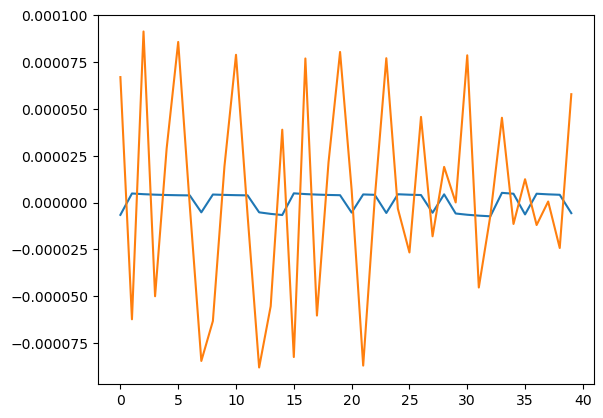

Frobenius Norm of Difference: 0.016411260448757507
------------------------------------
Mean Difference: 2.5708510624256015e-05
Standard Deviation of Difference: 5.2016255636526004e-05
Max Difference: 0.00018449795078201436
Min Difference: -0.00013299010542611178
------------------------------------


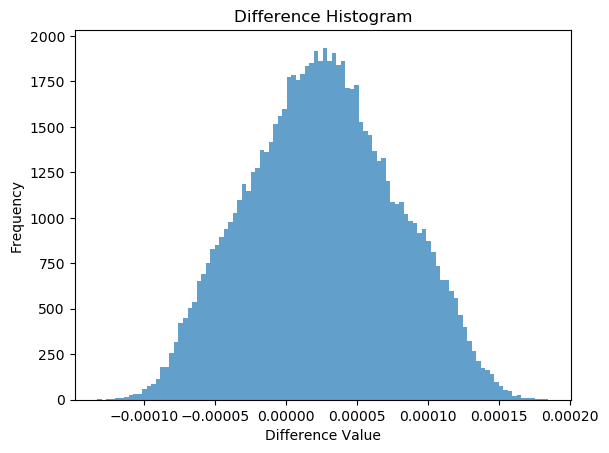

------------------------------------
Mean Pearson Correlation: 0.9997223693438506
Mean Spearman Correlation: 0.9996918471979617
------------------------------------


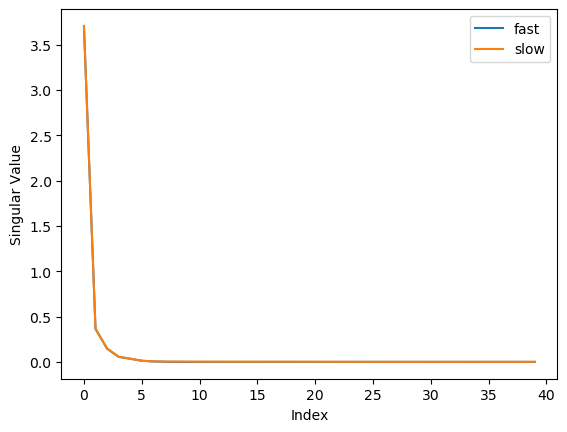

Cosine Similarity of Principal Directions: [ 0.99999952  0.99998015  0.99983869 -0.99895379 -0.99767641 -0.98111743
 -0.913962    0.00937672  0.00992038 -0.05631158  0.0686019   0.00623921
  0.00367186 -0.03252286 -0.00603116 -0.04698573  0.03114436 -0.11370189
  0.04037264 -0.01627904  0.01670967  0.00891166  0.00784327  0.03331573
  0.00548279 -0.03877671  0.04636327  0.00389885 -0.0853349  -0.02020546
 -0.00620339  0.00716715  0.00316547  0.00741691  0.02110554 -0.01686209
  0.05354664  0.01529671 -0.01702086  0.00368131]
Condition Number (fast): 13627542.953458048
Condition Number (slow): 3199.3513054262976
Effective Rank (fast): 4
Effective Rank (slow): 4
------------------------------------
Projection Error: 0.007847814139359343
------------------------------------


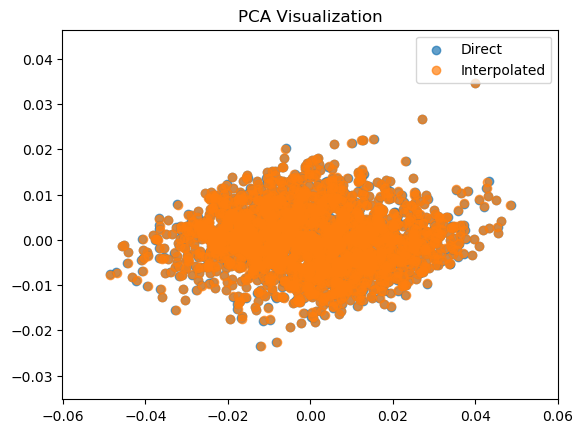

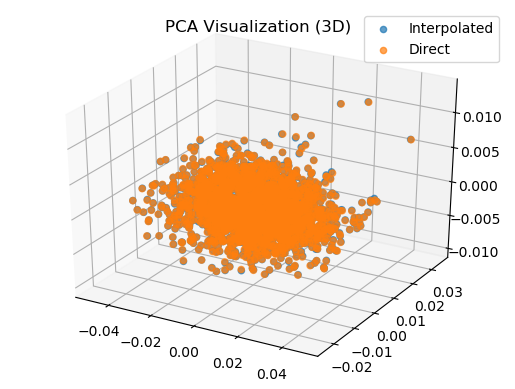

Wasserstein Distances for each PCA component:
Component 1: 4.4231490925887755e-05
Component 2: 2.424076857778804e-05
Component 3: 1.5658672477320287e-05
Component 4: 9.042202528128036e-06
Component 5: 7.847494726310097e-06
Component 6: 5.959190099829936e-06
Component 7: 9.428751869770547e-06
Component 8: 4.929367104575258e-05
Component 9: 6.69297196349011e-05
Component 10: 5.824966098505862e-05
Component 11: 5.5388922266381136e-05
Component 12: 5.1411730879969196e-05
Component 13: 5.0460907245344146e-05
Component 14: 4.974482991705591e-05
Component 15: 4.713856401645909e-05
Component 16: 4.553645050848253e-05
Component 17: 4.262816317327044e-05
Component 18: 4.154257450145337e-05
Component 19: 4.143595464706547e-05
Component 20: 4.01331469452196e-05
Component 21: 3.79850684402306e-05
Component 22: 3.3612844578142465e-05
Component 23: 3.371958442609885e-05
Component 24: 3.318195622199585e-05
Component 25: 3.14098569804557e-05
Component 26: 3.083569501266683e-05
Component 27: 2.985902572

In [55]:

from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr, spearmanr,wasserstein_distance


print(np.shape(s_trains))
print(np.shape(s_trainf))

# 1. Compute Difference Matrix
delta_X = s_trainf - s_trains

plt.figure()
plt.plot(delta_X[0,:])
plt.plot(delta_X[1,:])
plt.show()

# 2. Element-wise metrics
abs_diff = np.abs(delta_X)
square_diff = delta_X ** 2
frobenius_norm = np.linalg.norm(delta_X, ord='fro')
rel_diff = abs_diff / (np.abs(s_trains) + 1e-12)  # Avoid division by zero

print("Frobenius Norm of Difference:", frobenius_norm)
print('------------------------------------')

# 3. Statistical Analysis
mean_diff = np.mean(delta_X)
std_diff = np.std(delta_X)
max_diff = np.max(delta_X)
min_diff = np.min(delta_X)

print("Mean Difference:", mean_diff)
print("Standard Deviation of Difference:", std_diff)
print("Max Difference:", max_diff)
print("Min Difference:", min_diff)
print('------------------------------------')

# Histogram
plt.hist(delta_X.flatten(), bins=100, alpha=0.7)
plt.title("Difference Histogram")
plt.xlabel("Difference Value")
plt.ylabel("Frequency")
plt.show()
print('------------------------------------')

# 4. Correlation Analysis
pearson_corr = [pearsonr(s_trainf[:, i], s_trains[:, i])[0] for i in range(s_trainf.shape[1])]
spearman_corr = [spearmanr(s_trainf[:, i], s_trains[:, i])[0] for i in range(s_trainf.shape[1])]

print("Mean Pearson Correlation:", np.mean(pearson_corr))
print("Mean Spearman Correlation:", np.mean(spearman_corr))
print('------------------------------------')

# 5. Singular Value Decomposition (SVD)
U_interp, S_interp, Vt_interp = np.linalg.svd(s_trainf, full_matrices=False)
U_direct, S_direct, Vt_direct = np.linalg.svd(s_trains, full_matrices=False)

# Compare Singular Values
plt.plot(S_interp, label="fast")
plt.plot(S_direct, label="slow")

plt.xlabel("Index")
plt.ylabel("Singular Value")
plt.legend()
plt.show()

# 5.0 Compare Principal Directions (Cosine Similarity)
cosine_similarity = np.sum(U_interp * U_direct, axis=0) / (
    np.linalg.norm(U_interp, axis=0) * np.linalg.norm(U_direct, axis=0)
)

print("Cosine Similarity of Principal Directions:", cosine_similarity)

# 5.1 Condition Numbers
cond_interp = S_interp[0] / S_interp[-1] if S_interp[-1] > 1e-12 else np.inf
cond_direct = S_direct[0] / S_direct[-1] if S_direct[-1] > 1e-12 else np.inf

print("Condition Number (fast):", cond_interp)
print("Condition Number (slow):", cond_direct)

# 5.2 Effective Rank
def effective_rank(singular_values, threshold=0.01):
    normalized_singular_values = singular_values / np.sum(singular_values)
    return np.sum(normalized_singular_values > threshold)

effective_rank_interp = effective_rank(S_interp)
effective_rank_direct = effective_rank(S_direct)

print("Effective Rank (fast):", effective_rank_interp)
print("Effective Rank (slow):", effective_rank_direct)
print('------------------------------------')

# 6. Projection Error
P_direct = s_trainf @ np.linalg.pinv(s_trains)
R = s_trainf - P_direct @ s_trainf
projection_error = np.linalg.norm(R, ord='fro')
print("Projection Error:", projection_error)
print('------------------------------------')

# 7. Dimensionality Reduction and Visualization
pca = PCA(n_components=2)
X_interp_pca = pca.fit_transform(s_trainf)
X_direct_pca = pca.fit_transform(s_trains)

plt.scatter(X_direct_pca[:, 0], X_direct_pca[:, 1], alpha=0.7, label="Direct")
plt.scatter(X_interp_pca[:, 0], X_interp_pca[:, 1], alpha=0.7, label="Interpolated")

plt.title("PCA Visualization")
plt.legend()
plt.show()

# 7.1 Dimensionality Reduction and Visualization (3D)
from mpl_toolkits.mplot3d import Axes3D


pca_3d = PCA(n_components=3)
X_interp_pca_3d = pca_3d.fit_transform(s_trainf)
X_direct_pca_3d = pca_3d.fit_transform(s_trains)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_interp_pca_3d[:, 0], X_interp_pca_3d[:, 1], X_interp_pca_3d[:, 2], alpha=0.7, label="Interpolated")
ax.scatter(X_direct_pca_3d[:, 0], X_direct_pca_3d[:, 1], X_direct_pca_3d[:, 2], alpha=0.7, label="Direct")
ax.set_title("PCA Visualization (3D)")
ax.legend()
plt.show()

# 7.2 Wasserstein Distance Calculation (for all PCA components)
pca_full = PCA(n_components=min(s_trainf.shape[0], s_trainf.shape[1]))
X_interp_pca_full = pca_full.fit_transform(s_trainf)
X_direct_pca_full = pca_full.fit_transform(s_trains)

wasserstein_distances = [
    wasserstein_distance(X_interp_pca_full[:, i], X_direct_pca_full[:, i])
    for i in range(X_interp_pca_full.shape[1])
]

print("Wasserstein Distances for each PCA component:")
for i, wd in enumerate(wasserstein_distances):
    print(f"Component {i+1}: {wd}")




第三个：y_train(有误)

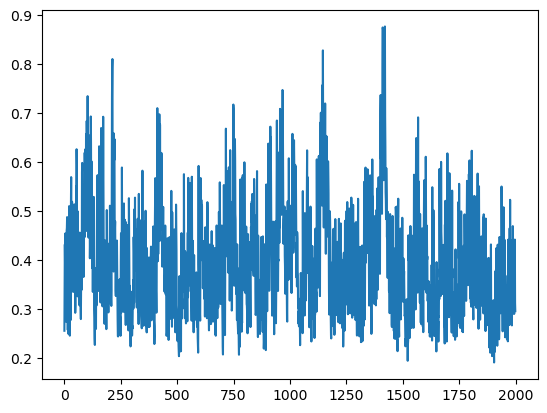

In [40]:
plt.figure()
plt.plot(y_train)
plt.show()

第四个：权重

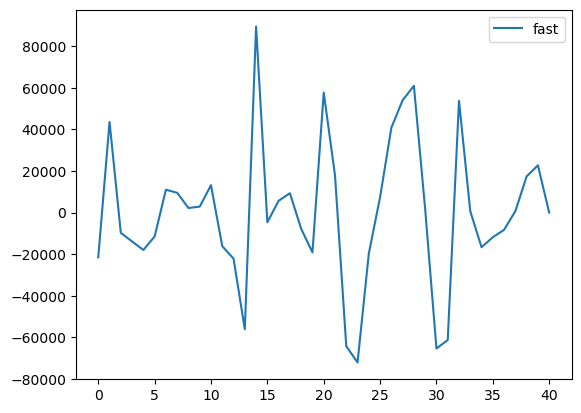

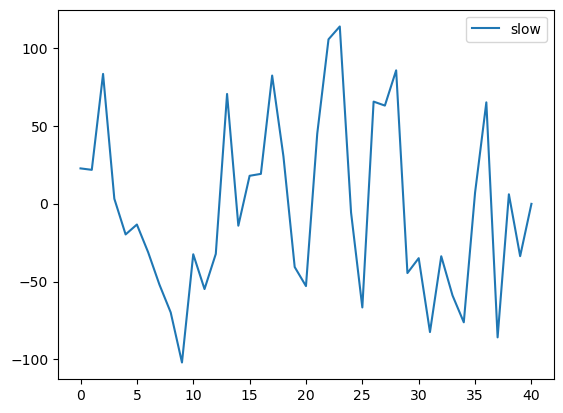

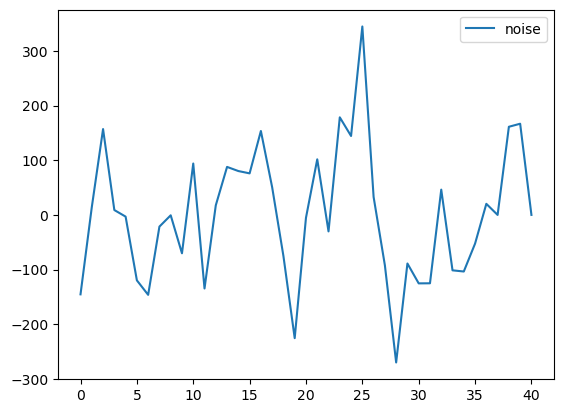

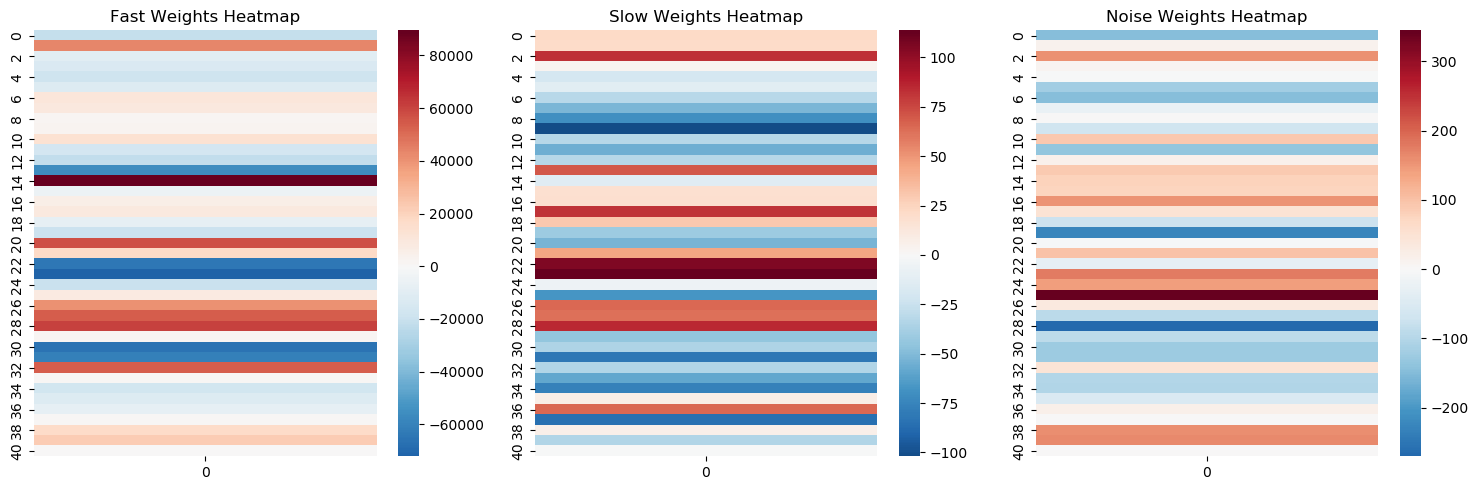

In [54]:
net_ff = np.array(net_fr.W).flatten()
net_ss = np.array(net_sr.W).flatten()
net_nn = np.array(net_n.W).flatten()

plt.figure()
plt.plot(net_ff,label='fast')
plt.legend()
plt.show()

plt.figure()
plt.plot(net_ss,label='slow')
plt.legend()
plt.show()

plt.figure()
plt.plot(net_nn,label='noise')
plt.legend()
plt.show()

import seaborn as sns

# 绘制热图
plt.figure(figsize=(15,5))

plt.subplot(131)
sns.heatmap(net_fr.W, cmap='RdBu_r', center=0)
plt.title('Fast Weights Heatmap')

plt.subplot(132)
sns.heatmap(net_sr.W, cmap='RdBu_r', center=0)
plt.title('Slow Weights Heatmap')

plt.subplot(133)
sns.heatmap(net_n.W, cmap='RdBu_r', center=0)
plt.title('Noise Weights Heatmap')

plt.tight_layout()
plt.show()

看看restart=False的案例中，有什么不同吧

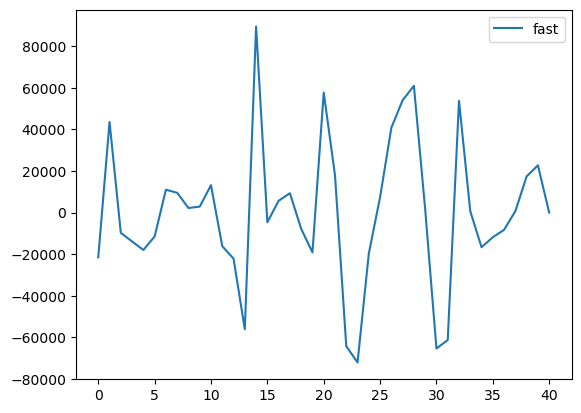

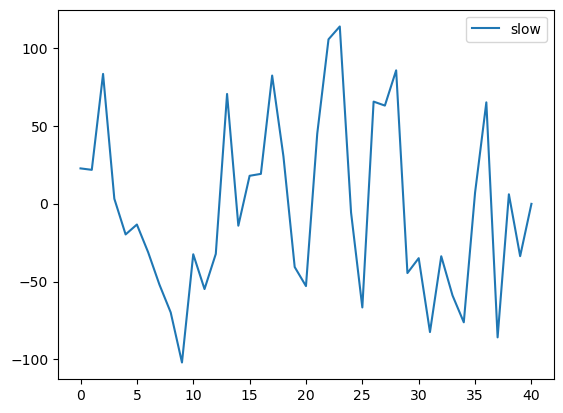

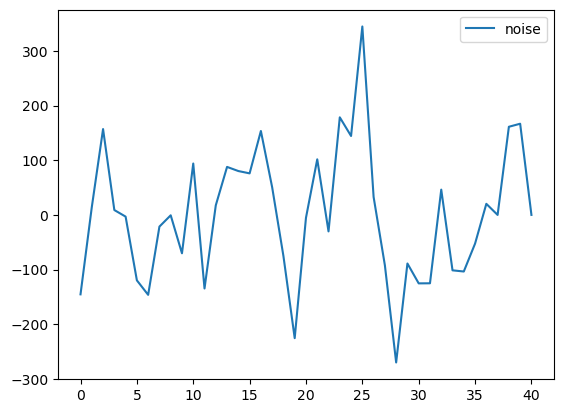

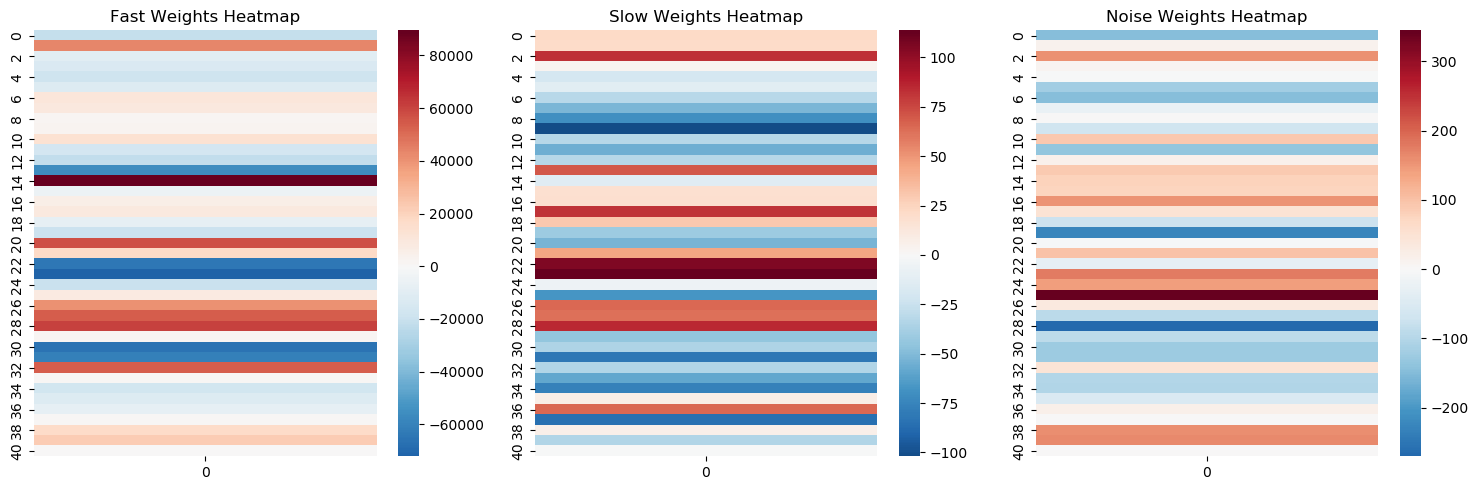

In [56]:
net_ff = np.array(net_f.W).flatten()
net_ss = np.array(net_s.W).flatten()
net_nn = np.array(net_n.W).flatten()

plt.figure()
plt.plot(net_ff,label='fast')
plt.legend()
plt.show()

plt.figure()
plt.plot(net_ss,label='slow')
plt.legend()
plt.show()

plt.figure()
plt.plot(net_nn,label='noise')
plt.legend()
plt.show()

import seaborn as sns

# 绘制热图
plt.figure(figsize=(15,5))

plt.subplot(131)
sns.heatmap(net_f.W, cmap='RdBu_r', center=0)
plt.title('Fast Weights Heatmap')

plt.subplot(132)
sns.heatmap(net_s.W, cmap='RdBu_r', center=0)
plt.title('Slow Weights Heatmap')

plt.subplot(133)
sns.heatmap(net_n.W, cmap='RdBu_r', center=0)
plt.title('Noise Weights Heatmap')

plt.tight_layout()
plt.show()

第五个：x_test

<Figure size 640x480 with 0 Axes>

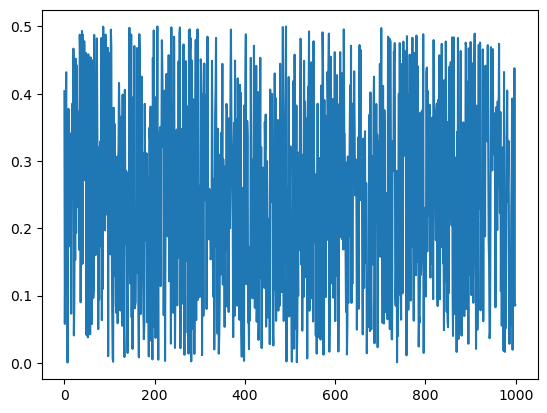

0.0


In [45]:
plt.figure()
plt.plot(x_testfr)
plt.show()

nrssss = NRMSE_list(x_testn,x_testf)
print(nrssss)

第六个：S_test

(1000, 40)
(1000, 40)


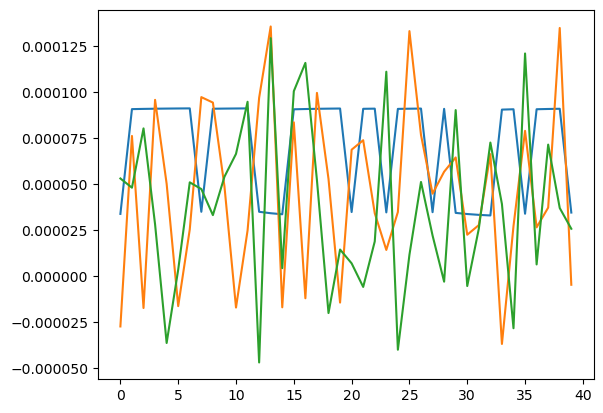

Frobenius Norm of Difference: 0.011606018574413166
------------------------------------
Mean Difference: 2.473700016442298e-05
Standard Deviation of Difference: 5.249354723778841e-05
Max Difference: 0.00018658505678631476
Min Difference: -0.00014445384160616248
------------------------------------


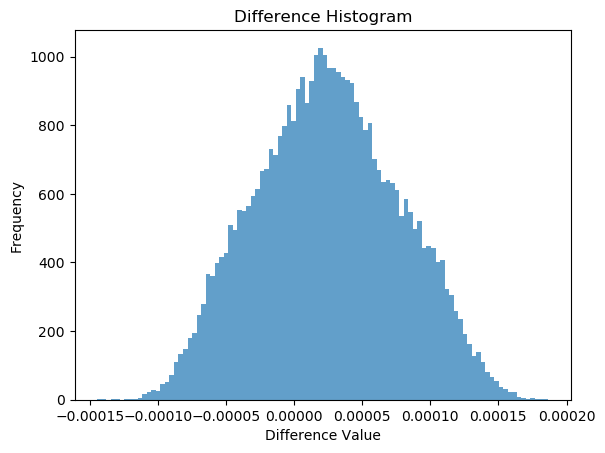

------------------------------------
Mean Pearson Correlation: 0.9997249838546456
Mean Spearman Correlation: 0.9996784287784287
------------------------------------


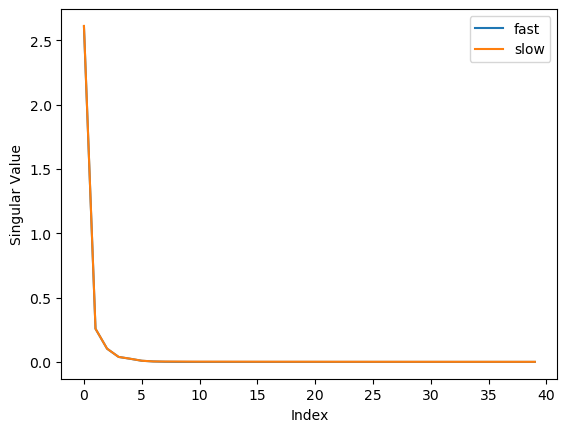

Cosine Similarity of Principal Directions: [ 0.9999995   0.99997826  0.99983418  0.99875244 -0.99747764 -0.97804989
 -0.90278788 -0.02335225 -0.02221439  0.01924448 -0.03401949 -0.04461897
 -0.00570499 -0.06147741 -0.05114692 -0.03266269 -0.03289444  0.02720935
 -0.03476178 -0.04171494  0.05875901  0.00960902  0.00917473  0.10160744
 -0.01806289 -0.03731451  0.0195049   0.04175085  0.01700369  0.03958082
  0.05330773 -0.10229087 -0.01069509  0.04014474  0.02858822  0.03423866
  0.01408944  0.06910567  0.01078248  0.0115571 ]
Condition Number (fast): 14186299.415425794
Condition Number (slow): 3355.930189364
Effective Rank (fast): 4
Effective Rank (slow): 4
------------------------------------
Projection Error: 0.005392278172314507
------------------------------------


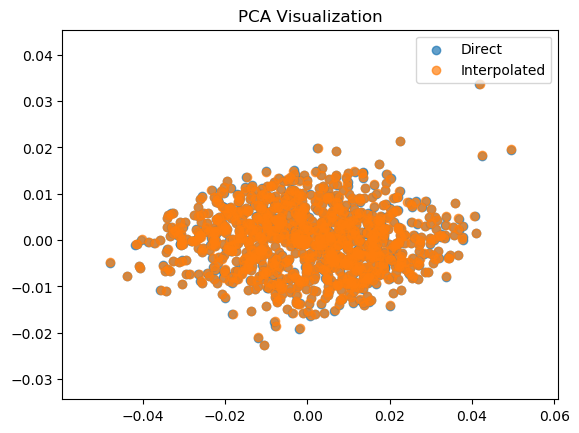

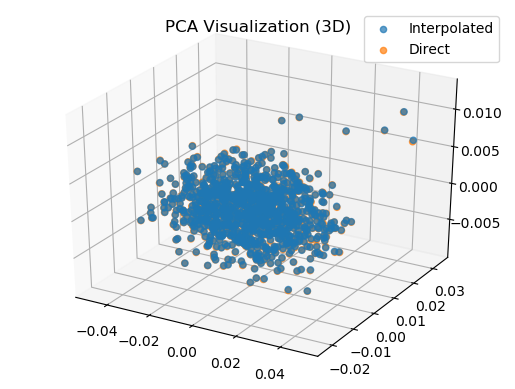

Wasserstein Distances for each PCA component:
Component 1: 5.2580304054768235e-05
Component 2: 3.1018881512756514e-05
Component 3: 1.8797091139868937e-05
Component 4: 1.3859309162928413e-05
Component 5: 1.1013773949760167e-05
Component 6: 7.622009827684679e-06
Component 7: 7.664078769766283e-06
Component 8: 5.083132089474539e-05
Component 9: 6.67237895048818e-05
Component 10: 5.887977940954155e-05
Component 11: 5.250866557941402e-05
Component 12: 5.305306008414206e-05
Component 13: 5.276643316884622e-05
Component 14: 5.084889834518397e-05
Component 15: 4.692187101453913e-05
Component 16: 4.401465408955443e-05
Component 17: 4.239166754642804e-05
Component 18: 4.10782789081356e-05
Component 19: 4.032261516239822e-05
Component 20: 3.8460839837446726e-05
Component 21: 3.8202495256865674e-05
Component 22: 3.5603869039262743e-05
Component 23: 3.344063620476101e-05
Component 24: 3.291530594877048e-05
Component 25: 3.1704833480153256e-05
Component 26: 3.018153807308653e-05
Component 27: 2.9350

In [48]:
print(np.shape(s_testsr))
print(np.shape(S_testfr))


# 1. Compute Difference Matrix
delta_X = S_testfr - s_testsr

plt.figure()
plt.plot(delta_X[0,:])
plt.plot(delta_X[1,:])
plt.plot(delta_X[2,:])
plt.show()

# 2. Element-wise metrics
abs_diff = np.abs(delta_X)
square_diff = delta_X ** 2
frobenius_norm = np.linalg.norm(delta_X, ord='fro')
rel_diff = abs_diff / (np.abs(s_testsr) + 1e-12)  # Avoid division by zero

print("Frobenius Norm of Difference:", frobenius_norm)
print('------------------------------------')

# 3. Statistical Analysis
mean_diff = np.mean(delta_X)
std_diff = np.std(delta_X)
max_diff = np.max(delta_X)
min_diff = np.min(delta_X)

print("Mean Difference:", mean_diff)
print("Standard Deviation of Difference:", std_diff)
print("Max Difference:", max_diff)
print("Min Difference:", min_diff)
print('------------------------------------')

# Histogram
plt.hist(delta_X.flatten(), bins=100, alpha=0.7)
plt.title("Difference Histogram")
plt.xlabel("Difference Value")
plt.ylabel("Frequency")
plt.show()
print('------------------------------------')

# 4. Correlation Analysis
pearson_corr = [pearsonr(S_testfr[:, i], s_testsr[:, i])[0] for i in range(S_testfr.shape[1])]
spearman_corr = [spearmanr(S_testfr[:, i], s_testsr[:, i])[0] for i in range(S_testfr.shape[1])]

print("Mean Pearson Correlation:", np.mean(pearson_corr))
print("Mean Spearman Correlation:", np.mean(spearman_corr))
print('------------------------------------')

# 5. Singular Value Decomposition (SVD)
U_interp, S_interp, Vt_interp = np.linalg.svd(S_testfr, full_matrices=False)
U_direct, S_direct, Vt_direct = np.linalg.svd(s_testsr, full_matrices=False)

# Compare Singular Values
plt.plot(S_interp, label="fast")
plt.plot(S_direct, label="slow")

plt.xlabel("Index")
plt.ylabel("Singular Value")
plt.legend()
plt.show()

# 5.0 Compare Principal Directions (Cosine Similarity)
cosine_similarity = np.sum(U_interp * U_direct, axis=0) / (
    np.linalg.norm(U_interp, axis=0) * np.linalg.norm(U_direct, axis=0)
)

print("Cosine Similarity of Principal Directions:", cosine_similarity)

# 5.1 Condition Numbers
cond_interp = S_interp[0] / S_interp[-1] if S_interp[-1] > 1e-12 else np.inf
cond_direct = S_direct[0] / S_direct[-1] if S_direct[-1] > 1e-12 else np.inf

print("Condition Number (fast):", cond_interp)
print("Condition Number (slow):", cond_direct)

# 5.2 Effective Rank
def effective_rank(singular_values, threshold=0.01):
    normalized_singular_values = singular_values / np.sum(singular_values)
    return np.sum(normalized_singular_values > threshold)

effective_rank_interp = effective_rank(S_interp)
effective_rank_direct = effective_rank(S_direct)

print("Effective Rank (fast):", effective_rank_interp)
print("Effective Rank (slow):", effective_rank_direct)
print('------------------------------------')

# 6. Projection Error
P_direct = S_testfr @ np.linalg.pinv(s_testsr)
R = S_testfr - P_direct @ S_testfr
projection_error = np.linalg.norm(R, ord='fro')
print("Projection Error:", projection_error)
print('------------------------------------')

# 7. Dimensionality Reduction and Visualization
pca = PCA(n_components=2)
X_interp_pca = pca.fit_transform(S_testfr)
X_direct_pca = pca.fit_transform(s_testsr)

plt.scatter(X_direct_pca[:, 0], X_direct_pca[:, 1], alpha=0.7, label="Direct")
plt.scatter(X_interp_pca[:, 0], X_interp_pca[:, 1], alpha=0.7, label="Interpolated")

plt.title("PCA Visualization")
plt.legend()
plt.show()

# 7.1 Dimensionality Reduction and Visualization (3D)
from mpl_toolkits.mplot3d import Axes3D


pca_3d = PCA(n_components=3)
X_interp_pca_3d = pca_3d.fit_transform(S_testfr)
X_direct_pca_3d = pca_3d.fit_transform(s_testsr)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_interp_pca_3d[:, 0], X_interp_pca_3d[:, 1], X_interp_pca_3d[:, 2], alpha=0.7, label="Interpolated")
ax.scatter(X_direct_pca_3d[:, 0], X_direct_pca_3d[:, 1], X_direct_pca_3d[:, 2], alpha=0.7, label="Direct")
ax.set_title("PCA Visualization (3D)")
ax.legend()
plt.show()

# 7.2 Wasserstein Distance Calculation (for all PCA components)
pca_full = PCA(n_components=min(S_testfr.shape[0], S_testfr.shape[1]))
X_interp_pca_full = pca_full.fit_transform(S_testfr)
X_direct_pca_full = pca_full.fit_transform(s_testsr)

wasserstein_distances = [
    wasserstein_distance(X_interp_pca_full[:, i], X_direct_pca_full[:, i])
    for i in range(X_interp_pca_full.shape[1])
]

print("Wasserstein Distances for each PCA component:")
for i, wd in enumerate(wasserstein_distances):
    print(f"Component {i+1}: {wd}")


重点来了：让我们看看restart=False的案例中，s_test有什么不同吧

(1000, 40)
(1000, 40)


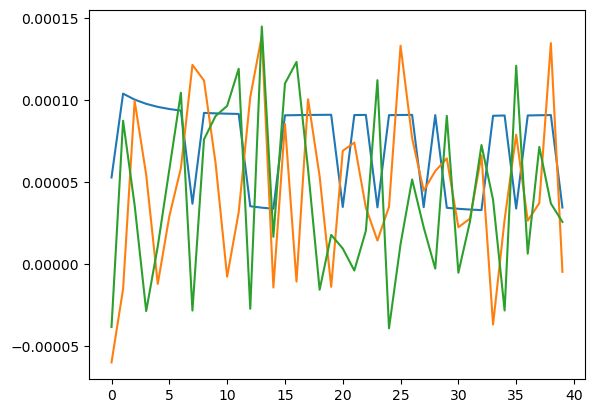

Frobenius Norm of Difference: 0.011615572516493075
------------------------------------
Mean Difference: 2.478835470021028e-05
Standard Deviation of Difference: 5.252214383861625e-05
Max Difference: 0.00018665554473296098
Min Difference: -0.000144437826090138
------------------------------------


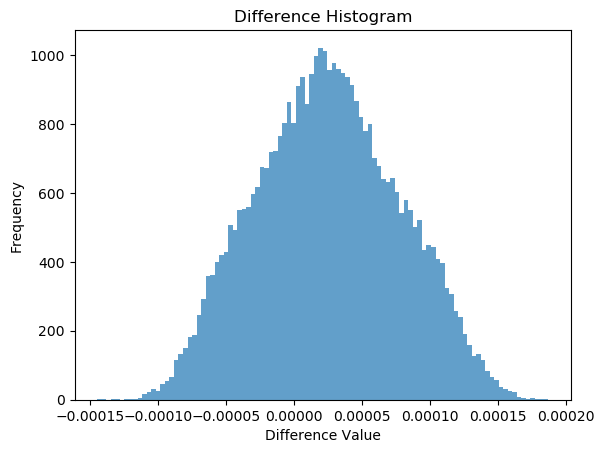

------------------------------------
Mean Pearson Correlation: 0.9997224064312791
Mean Spearman Correlation: 0.9996780606780608
------------------------------------


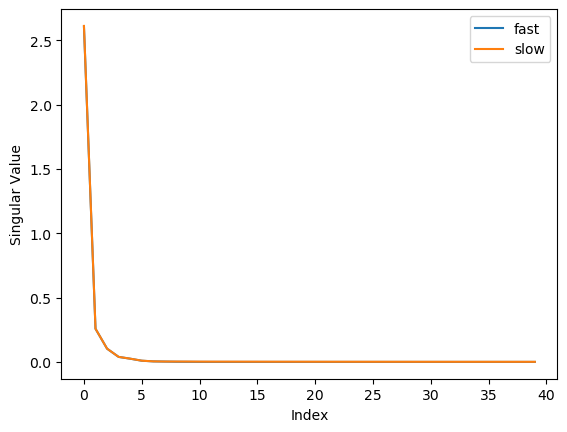

Cosine Similarity of Principal Directions: [ 0.9999995   0.99997821 -0.99983453  0.99876551  0.99760812 -0.97987366
 -0.93144889  0.55333505 -0.02615786 -0.06673707  0.05029398  0.01002275
  0.05871815 -0.03229134  0.00368293 -0.01775418  0.02933724 -0.08253503
  0.03965036 -0.08725524  0.01278803  0.04626208 -0.01755028 -0.07912988
 -0.00108916 -0.04935076 -0.02789052 -0.03921078  0.07012206 -0.00621409
 -0.04046746 -0.01019688  0.05388541  0.06764506 -0.06067941  0.03300544
 -0.0428468  -0.03674285 -0.03776601  0.03339149]
Condition Number (fast): 9100845.075011471
Condition Number (slow): 3353.9770454674926
Effective Rank (fast): 4
Effective Rank (slow): 4
------------------------------------
Projection Error: 0.005466833063824766
------------------------------------


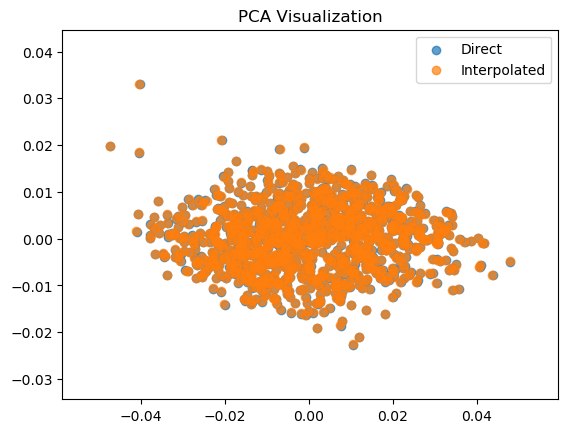

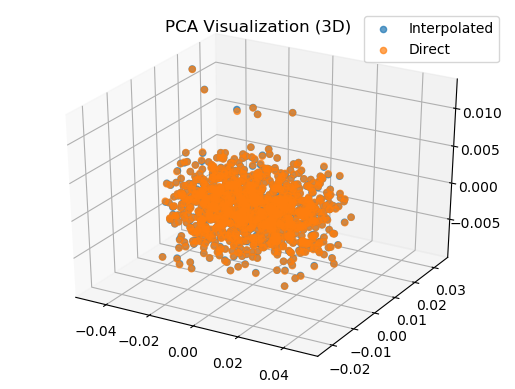

Wasserstein Distances for each PCA component:
Component 1: 5.274202767207983e-05
Component 2: 3.0738425825082406e-05
Component 3: 1.9312866264408012e-05
Component 4: 1.2755541732629759e-05
Component 5: 1.1449127412900897e-05
Component 6: 7.935743817437157e-06
Component 7: 8.566504297459954e-06
Component 8: 3.337945669658407e-05
Component 9: 5.752876322946336e-05
Component 10: 5.0222771244740226e-05
Component 11: 5.5316539070544466e-05
Component 12: 5.135773358597748e-05
Component 13: 5.2845343690485176e-05
Component 14: 5.075448441133339e-05
Component 15: 4.93269788597784e-05
Component 16: 4.65691486260556e-05
Component 17: 4.4485850916149233e-05
Component 18: 4.301214403570592e-05
Component 19: 4.255167376136908e-05
Component 20: 3.912981965021388e-05
Component 21: 3.797533832966378e-05
Component 22: 3.584873134107348e-05
Component 23: 3.584674598784246e-05
Component 24: 3.355610767285116e-05
Component 25: 3.1680015694428946e-05
Component 26: 3.1736895233227646e-05
Component 27: 2.989

In [57]:
print(np.shape(s_tests))
print(np.shape(s_testf))


# 1. Compute Difference Matrix
delta_X = s_testf - s_tests

plt.figure()
plt.plot(delta_X[0,:])
plt.plot(delta_X[1,:])
plt.plot(delta_X[2,:])
plt.show()

# 2. Element-wise metrics
abs_diff = np.abs(delta_X)
square_diff = delta_X ** 2
frobenius_norm = np.linalg.norm(delta_X, ord='fro')
rel_diff = abs_diff / (np.abs(s_tests) + 1e-12)  # Avoid division by zero

print("Frobenius Norm of Difference:", frobenius_norm)
print('------------------------------------')

# 3. Statistical Analysis
mean_diff = np.mean(delta_X)
std_diff = np.std(delta_X)
max_diff = np.max(delta_X)
min_diff = np.min(delta_X)

print("Mean Difference:", mean_diff)
print("Standard Deviation of Difference:", std_diff)
print("Max Difference:", max_diff)
print("Min Difference:", min_diff)
print('------------------------------------')

# Histogram
plt.hist(delta_X.flatten(), bins=100, alpha=0.7)
plt.title("Difference Histogram")
plt.xlabel("Difference Value")
plt.ylabel("Frequency")
plt.show()
print('------------------------------------')

# 4. Correlation Analysis
pearson_corr = [pearsonr(s_testf[:, i], s_tests[:, i])[0] for i in range(s_testf.shape[1])]
spearman_corr = [spearmanr(s_testf[:, i], s_tests[:, i])[0] for i in range(s_testf.shape[1])]

print("Mean Pearson Correlation:", np.mean(pearson_corr))
print("Mean Spearman Correlation:", np.mean(spearman_corr))
print('------------------------------------')

# 5. Singular Value Decomposition (SVD)
U_interp, S_interp, Vt_interp = np.linalg.svd(s_testf, full_matrices=False)
U_direct, S_direct, Vt_direct = np.linalg.svd(s_tests, full_matrices=False)

# Compare Singular Values
plt.plot(S_interp, label="fast")
plt.plot(S_direct, label="slow")

plt.xlabel("Index")
plt.ylabel("Singular Value")
plt.legend()
plt.show()

# 5.0 Compare Principal Directions (Cosine Similarity)
cosine_similarity = np.sum(U_interp * U_direct, axis=0) / (
    np.linalg.norm(U_interp, axis=0) * np.linalg.norm(U_direct, axis=0)
)

print("Cosine Similarity of Principal Directions:", cosine_similarity)

# 5.1 Condition Numbers
cond_interp = S_interp[0] / S_interp[-1] if S_interp[-1] > 1e-12 else np.inf
cond_direct = S_direct[0] / S_direct[-1] if S_direct[-1] > 1e-12 else np.inf

print("Condition Number (fast):", cond_interp)
print("Condition Number (slow):", cond_direct)

# 5.2 Effective Rank
def effective_rank(singular_values, threshold=0.01):
    normalized_singular_values = singular_values / np.sum(singular_values)
    return np.sum(normalized_singular_values > threshold)

effective_rank_interp = effective_rank(S_interp)
effective_rank_direct = effective_rank(S_direct)

print("Effective Rank (fast):", effective_rank_interp)
print("Effective Rank (slow):", effective_rank_direct)
print('------------------------------------')

# 6. Projection Error
P_direct = s_testf @ np.linalg.pinv(s_tests)
R = s_testf - P_direct @ s_testf
projection_error = np.linalg.norm(R, ord='fro')
print("Projection Error:", projection_error)
print('------------------------------------')

# 7. Dimensionality Reduction and Visualization
pca = PCA(n_components=2)
X_interp_pca = pca.fit_transform(s_testf)
X_direct_pca = pca.fit_transform(s_tests)

plt.scatter(X_direct_pca[:, 0], X_direct_pca[:, 1], alpha=0.7, label="Direct")
plt.scatter(X_interp_pca[:, 0], X_interp_pca[:, 1], alpha=0.7, label="Interpolated")

plt.title("PCA Visualization")
plt.legend()
plt.show()

# 7.1 Dimensionality Reduction and Visualization (3D)
from mpl_toolkits.mplot3d import Axes3D


pca_3d = PCA(n_components=3)
X_interp_pca_3d = pca_3d.fit_transform(s_testf)
X_direct_pca_3d = pca_3d.fit_transform(s_tests)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_interp_pca_3d[:, 0], X_interp_pca_3d[:, 1], X_interp_pca_3d[:, 2], alpha=0.7, label="Interpolated")
ax.scatter(X_direct_pca_3d[:, 0], X_direct_pca_3d[:, 1], X_direct_pca_3d[:, 2], alpha=0.7, label="Direct")
ax.set_title("PCA Visualization (3D)")
ax.legend()
plt.show()

# 7.2 Wasserstein Distance Calculation (for all PCA components)
pca_full = PCA(n_components=min(s_testf.shape[0], s_testf.shape[1]))
X_interp_pca_full = pca_full.fit_transform(s_testf)
X_direct_pca_full = pca_full.fit_transform(s_tests)

wasserstein_distances = [
    wasserstein_distance(X_interp_pca_full[:, i], X_direct_pca_full[:, i])
    for i in range(X_interp_pca_full.shape[1])
]

print("Wasserstein Distances for each PCA component:")
for i, wd in enumerate(wasserstein_distances):
    print(f"Component {i+1}: {wd}")


第七个：pred

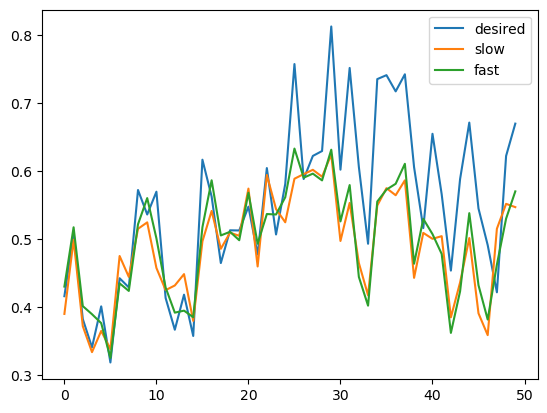

In [58]:
spac = 20
windows = 50
plt.figure()
plt.plot(y_test[spac:spac+windows],label='desired')
plt.plot(y_s[spac:spac+windows],label='slow')
plt.plot(y_f[spac:spac+windows],label='fast') 
# plt.plot(y_n,label='noise')
plt.legend()
plt.show()

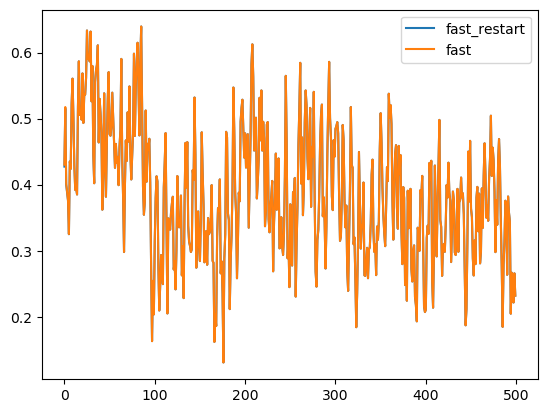

In [60]:
spac = 20
windows = 500
plt.figure()

plt.plot(y_fr[spac:spac+windows],label='fast_restart')
plt.plot(y_f[spac:spac+windows],label='fast') 
# plt.plot(y_n,label='noise')
plt.legend()
plt.show()

# Fast with force-regularation

seed warmup: 1234
length warmup: 0
seed NARMA: 1234
Nwarmup: 0
Samples for training:  2000
Samples for test:  1000
Nin = 1 , Nout =  2000 , Nvirt =  40
Deterministic mask will be used
1234
current phase: warmup
p1 in warmup & fast: 0.4999998889492148
current phase: train
p1 in train & fast: 0.4999998889492148
noise-free training output
restarted
Training data size:  80000
Training data shape:  (2000, 40)
Seed Training: 1234
error with zero =  0.0033847981091504574
l= 4.5399929762484854e-05 0.004384336979609115
lambda=4.5399929762484854e-05: MSE=0.004384336979609115
Current weights: [[ 7.47991004e+00]
 [ 8.27565224e+00]
 [-3.06756574e-01]
 [-1.21994233e+01]
 [-2.13063731e+01]
 [-2.56746877e+01]
 [-2.55483963e+01]
 [-3.79817057e+01]
 [-2.32792837e+01]
 [-1.36198407e+01]
 [-8.84363084e+00]
 [-5.26589997e+00]
 [-1.71737374e+01]
 [-1.90104753e+01]
 [-1.68070746e+01]
 [-8.61817048e-03]
 [ 5.22930017e+00]
 [ 5.47756773e+00]
 [ 6.79356102e+00]
 [ 1.08497464e+01]
 [ 1.29891020e+00]
 [ 1.7819400

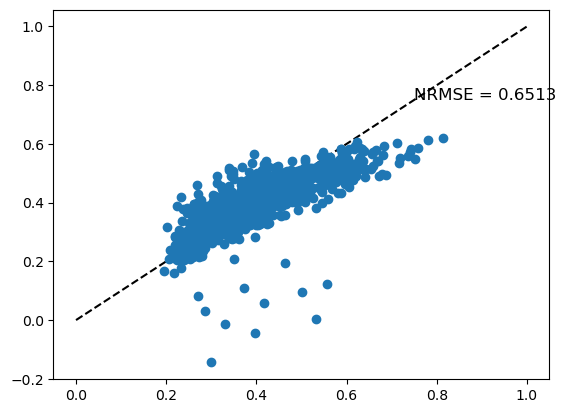

In [2]:
# NARMA10 parameters
Ntrain = 2000
Ntest = 1000
Nwarmup = 0

# Net parameters
Nvirt = 40
m0 = 1e-2
bias = True

# Reservoir parameters
h = 0.4
theta_H = 90
k_s_0 = 0
phi = 45
beta_prime = 10

# Params
params = {
    'theta':1/3, 
    'gamma':.25, 
    'delay_feedback':0, 
    'Nvirt':Nvirt,
    'noise_enable': 'None',
    'noise_seed': 1234,
    'noise_mean':0.0001,
    'noise_std':0.00013,
    'seed_warmup': 1234,
    'length_warmup': Nwarmup,
    'train_sample': Ntrain*Nvirt,
    'test_sample': Ntest*Nvirt,
    'warmup_sample': Nwarmup*Nvirt,
}

spn = spnc_anisotropy(h, theta_H, k_s_0, phi, beta_prime,restart = True,Primep1=None)
transformf = spn.gen_signal_fast_delayed_feedback


# run
(nrmsefrf,y_testrf,y_frf,y_trainrf,s_frf,net_frf,x_trainfrf,s_trainfrf,x_testfrf,S_testfrf) = ml.spnc_narma10_weight(Ntrain,Ntest,Nvirt,m0,bias,transformf,params,seed_NARMA=1234,fixed_mask=True,return_all=True, Nwarmup=0)

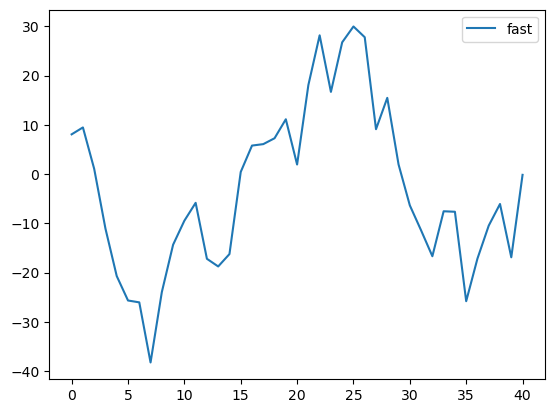

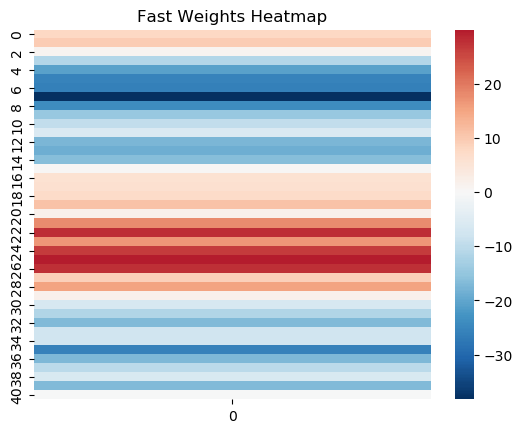

In [5]:
net_ff = np.array(net_frf.W).flatten()


plt.figure()
plt.plot(net_ff,label='fast')
plt.legend()
plt.show()

import seaborn as sns

# 绘制热图
plt.figure()
sns.heatmap(net_frf.W, cmap='RdBu_r', center=0)
plt.title('Fast Weights Heatmap')
plt.show()



# use new testing set on the fast

seed warmup: 1234
length warmup: 0
seed NARMA: 1234
Nwarmup: 0
Old testing set is used
Old testing set seed: 1234
Samples for training:  2000
Samples for test:  1000
Nin = 1 , Nout =  2000 , Nvirt =  40
Deterministic mask will be used
1234
current phase: warmup
p1 in warmup & fast: 0.4999998889492148
current phase: train
p1 in train & fast: 0.4999998889492148
noise-free training output
restarted
Training data size:  80000
Training data shape:  (2000, 40)
Seed Training: 1234
error with zero =  0.0033847981091504574
l= 4.5399929762484854e-05 0.004384336979609115
lambda=4.5399929762484854e-05: MSE=0.004384336979609115
Current weights: [[ 7.47991004e+00]
 [ 8.27565224e+00]
 [-3.06756574e-01]
 [-1.21994233e+01]
 [-2.13063731e+01]
 [-2.56746877e+01]
 [-2.55483963e+01]
 [-3.79817057e+01]
 [-2.32792837e+01]
 [-1.36198407e+01]
 [-8.84363084e+00]
 [-5.26589997e+00]
 [-1.71737374e+01]
 [-1.90104753e+01]
 [-1.68070746e+01]
 [-8.61817048e-03]
 [ 5.22930017e+00]
 [ 5.47756773e+00]
 [ 6.79356102e+00]

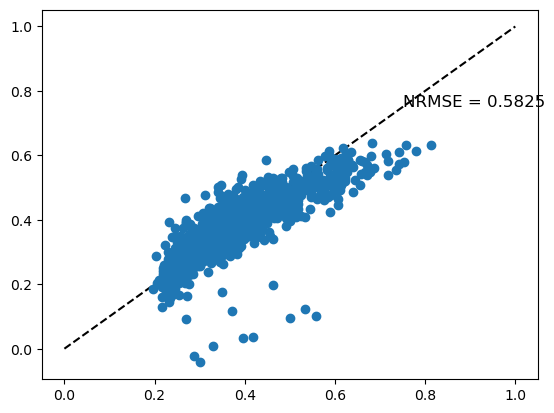

seed warmup: 1234
length warmup: 0
seed NARMA: 1234
Nwarmup: 0
Old testing set is used
Old testing set seed: 1234
Samples for training:  2000
Samples for test:  1000
Nin = 1 , Nout =  2000 , Nvirt =  40
Deterministic mask will be used
1234
current phase: warmup
p1 in warmup & slow: 0.4999998889492148
current phase: train
p1 in train & slow: 0.4999998889492148
noise_seed: 1234
noise_mean_train: 0.0001
noise-free training output
restarted
Training data size:  80000
Training data shape:  (2000, 40)
Seed Training: 1234
error with zero =  0.004380562850294669
l= 4.5399929762484854e-05 0.004456481437081064
lambda=4.5399929762484854e-05: MSE=0.004456481437081064
Current weights: [[  7.60437401]
 [  5.8876537 ]
 [ -1.04108387]
 [-16.90186923]
 [-21.76650928]
 [-21.06486875]
 [-25.81491046]
 [-37.35104418]
 [-20.96158947]
 [-16.27331111]
 [ -6.75195342]
 [ -3.57510736]
 [-18.38793318]
 [-12.24282477]
 [-18.36978005]
 [  3.57521584]
 [  3.67813362]
 [  9.84360425]
 [  3.66461435]
 [  8.00757195]

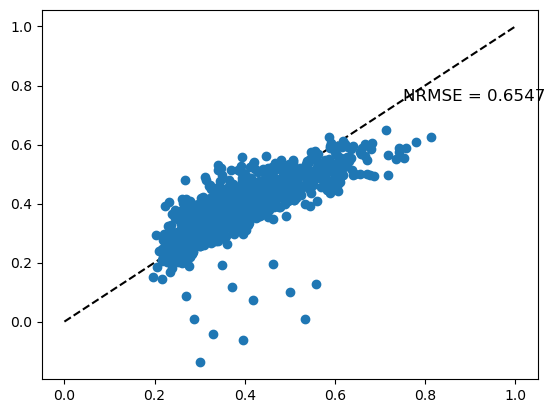

In [3]:
# NARMA10 parameters
Ntrain = 2000
Ntest = 1000
Nwarmup = 0

# Net parameters
Nvirt = 40
m0 = 1e-2
bias = True

# Reservoir parameters
h = 0.4
theta_H = 90
k_s_0 = 0
phi = 45
beta_prime = 10

# Params
params = {
    'theta':1/3, 
    'gamma':.25, 
    'delay_feedback':0, 
    'Nvirt':Nvirt,
    'noise_enable': 'None',
    'noise_seed': 1234,
    'noise_mean':0.0001,
    'noise_std':0.00013,
    'seed_warmup': 1234,
    'length_warmup': Nwarmup,
    'train_sample': Ntrain*Nvirt,
    'test_sample': Ntest*Nvirt,
    'warmup_sample': Nwarmup*Nvirt,
}

spn = spnc_anisotropy(h, theta_H, k_s_0, phi, beta_prime,restart = True,Primep1=None)
transformf = spn.gen_signal_fast_delayed_feedback
transforms = spn.gen_signal_slow_delayed_feedback

# run
(nrmseft,y_testt,y_ft,y_traint,s_ft,net_ft,x_trainft,s_trainft,x_testft,S_testft) = ml.spnc_narma10_newtestingset(Ntrain,Ntest,Nvirt,m0,bias,transformf,params,seed_NARMA=1234,fixed_mask=True,return_all=True, Nwarmup=0,newtestingset=None)
(nrmsest,y_testt,y_st,y_traint,s_st,net_st,x_trainst,s_trainst,x_testst,s_testst) = ml.spnc_narma10_newtestingset(Ntrain,Ntest,Nvirt,m0,bias,transforms,params,seed_NARMA=1234,fixed_mask=True,return_all=True, Nwarmup=0,newtestingset=None)

seed warmup: 1234
length warmup: 0
seed NARMA: 1234
Nwarmup: 0
New testing set is used
New testing set seed: 12
Samples for training:  2000
Samples for test:  1000
Nin = 1 , Nout =  2000 , Nvirt =  40
Deterministic mask will be used
1234
current phase: warmup
p1 in warmup & fast: 0.4999998889492148
current phase: train
p1 in train & fast: 0.4999998889492148
noise-free training output
restarted
Training data size:  80000
Training data shape:  (2000, 40)
Seed Training: 1234
error with zero =  0.0033847981091504574
l= 4.5399929762484854e-05 0.004384336979609115
lambda=4.5399929762484854e-05: MSE=0.004384336979609115
Current weights: [[ 7.47991004e+00]
 [ 8.27565224e+00]
 [-3.06756574e-01]
 [-1.21994233e+01]
 [-2.13063731e+01]
 [-2.56746877e+01]
 [-2.55483963e+01]
 [-3.79817057e+01]
 [-2.32792837e+01]
 [-1.36198407e+01]
 [-8.84363084e+00]
 [-5.26589997e+00]
 [-1.71737374e+01]
 [-1.90104753e+01]
 [-1.68070746e+01]
 [-8.61817048e-03]
 [ 5.22930017e+00]
 [ 5.47756773e+00]
 [ 6.79356102e+00]
 

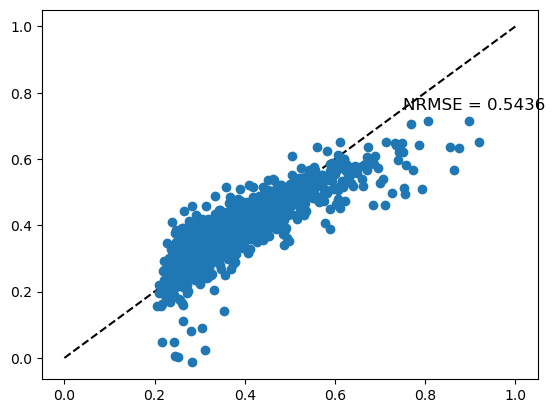

seed warmup: 1234
length warmup: 0
seed NARMA: 1234
Nwarmup: 0
New testing set is used
New testing set seed: 12
Samples for training:  2000
Samples for test:  1000
Nin = 1 , Nout =  2000 , Nvirt =  40
Deterministic mask will be used
1234
current phase: warmup
p1 in warmup & slow: 0.4999998889492148
current phase: train
p1 in train & slow: 0.4999998889492148
noise_seed: 1234
noise_mean_train: 0.0001
noise-free training output
restarted
Training data size:  80000
Training data shape:  (2000, 40)
Seed Training: 1234
error with zero =  0.004380562850294669
l= 4.5399929762484854e-05 0.004456481437081064
lambda=4.5399929762484854e-05: MSE=0.004456481437081064
Current weights: [[  7.60437401]
 [  5.8876537 ]
 [ -1.04108387]
 [-16.90186923]
 [-21.76650928]
 [-21.06486875]
 [-25.81491046]
 [-37.35104418]
 [-20.96158947]
 [-16.27331111]
 [ -6.75195342]
 [ -3.57510736]
 [-18.38793318]
 [-12.24282477]
 [-18.36978005]
 [  3.57521584]
 [  3.67813362]
 [  9.84360425]
 [  3.66461435]
 [  8.00757195]
 

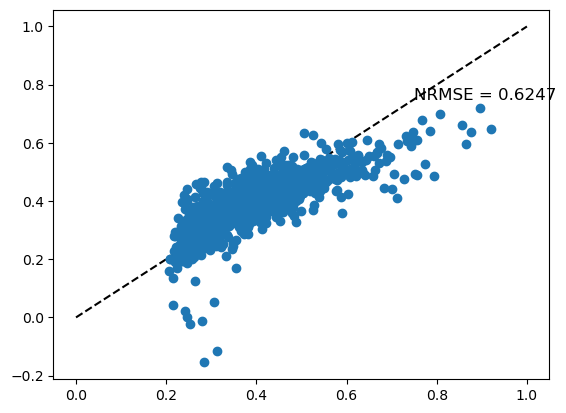

In [4]:
# NARMA10 parameters
Ntrain = 2000
Ntest = 1000
Nwarmup = 0

# Net parameters
Nvirt = 40
m0 = 1e-2
bias = True

# Reservoir parameters
h = 0.4
theta_H = 90
k_s_0 = 0
phi = 45
beta_prime = 10

# Params
params = {
    'theta':1/3, 
    'gamma':.25, 
    'delay_feedback':0, 
    'Nvirt':Nvirt,
    'noise_enable': 'None',
    'noise_seed': 1234,
    'noise_mean':0.0001,
    'noise_std':0.00013,
    'seed_warmup': 1234,
    'length_warmup': Nwarmup,
    'train_sample': Ntrain*Nvirt,
    'test_sample': Ntest*Nvirt,
    'warmup_sample': Nwarmup*Nvirt,
}

spn = spnc_anisotropy(h, theta_H, k_s_0, phi, beta_prime,restart = True,Primep1=None)
transformf = spn.gen_signal_fast_delayed_feedback
transforms = spn.gen_signal_slow_delayed_feedback

# run
(nrmseft,y_testt,y_ft,y_traint,s_ft,net_ft,x_trainft,s_trainft,x_testft,S_testft) = ml.spnc_narma10_newtestingset(Ntrain,Ntest,Nvirt,m0,bias,transformf,params,seed_NARMA=1234,fixed_mask=True,return_all=True, Nwarmup=0,newtestingset=12)
(nrmsest,y_testt,y_st,y_traint,s_st,net_st,x_trainst,s_trainst,x_testst,s_testst) = ml.spnc_narma10_newtestingset(Ntrain,Ntest,Nvirt,m0,bias,transforms,params,seed_NARMA=1234,fixed_mask=True,return_all=True, Nwarmup=0,newtestingset=12)

seed warmup: 1234
length warmup: 0
seed NARMA: 1234
Nwarmup: 0
New testing set is used
New testing set seed: 12
Samples for training:  2000
Samples for test:  1000
Nin = 1 , Nout =  2000 , Nvirt =  40
Deterministic mask will be used
1234
current phase: warmup
p1 in warmup & fast: 0.4999998889492148
current phase: train
p1 in train & fast: 0.4999998889492148
noise-free training output
skip restarting..
Training data size:  80000
Training data shape:  (2000, 40)
Seed Training: 1234
error with zero =  0.0033847981091504574
l= 4.5399929762484854e-05 0.004384336979609115
lambda=4.5399929762484854e-05: MSE=0.004384336979609115
Current weights: [[ 7.47991004e+00]
 [ 8.27565224e+00]
 [-3.06756574e-01]
 [-1.21994233e+01]
 [-2.13063731e+01]
 [-2.56746877e+01]
 [-2.55483963e+01]
 [-3.79817057e+01]
 [-2.32792837e+01]
 [-1.36198407e+01]
 [-8.84363084e+00]
 [-5.26589997e+00]
 [-1.71737374e+01]
 [-1.90104753e+01]
 [-1.68070746e+01]
 [-8.61817048e-03]
 [ 5.22930017e+00]
 [ 5.47756773e+00]
 [ 6.7935610

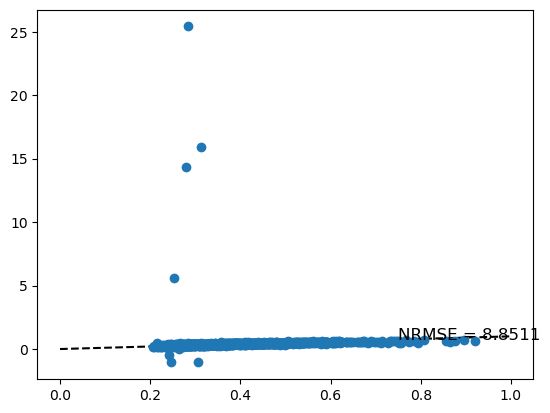

seed warmup: 1234
length warmup: 0
seed NARMA: 1234
Nwarmup: 0
New testing set is used
New testing set seed: 12
Samples for training:  2000
Samples for test:  1000
Nin = 1 , Nout =  2000 , Nvirt =  40
Deterministic mask will be used
1234
current phase: warmup
p1 in warmup & slow: [0.49498388]
current phase: train
p1 in train & slow: [0.49498388]
noise_seed: 1234
noise_mean_train: 0.0001
noise-free training output
skip restarting..
Training data size:  80000
Training data shape:  (2000, 40)
Seed Training: 1234
error with zero =  0.004338545674989099
l= 4.5399929762484854e-05 0.00422437028486654
lambda=4.5399929762484854e-05: MSE=0.00422437028486654
Current weights: [[ -3.84463286]
 [  2.2096652 ]
 [ -1.3079331 ]
 [-17.85348565]
 [-22.63263566]
 [-20.66594053]
 [-25.57377871]
 [-37.85508147]
 [-18.27626082]
 [-13.00007566]
 [ -5.06959394]
 [ -1.6803058 ]
 [-19.31188774]
 [-13.28834564]
 [-19.89544383]
 [  2.60360443]
 [  2.3182345 ]
 [  4.63695126]
 [ -0.81277593]
 [  2.48027514]
 [-10.0

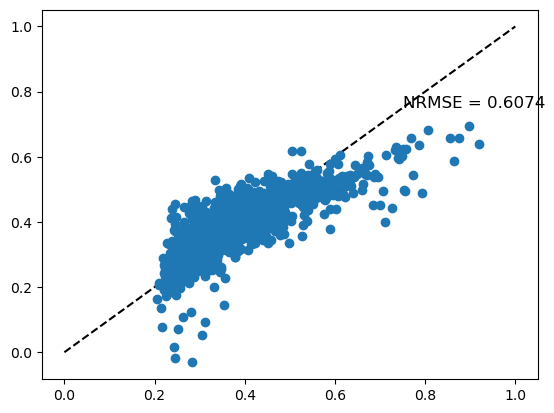

In [5]:
# NARMA10 parameters
Ntrain = 2000
Ntest = 1000
Nwarmup = 0

# Net parameters
Nvirt = 40
m0 = 1e-2
bias = True

# Reservoir parameters
h = 0.4
theta_H = 90
k_s_0 = 0
phi = 45
beta_prime = 10

# Params
params = {
    'theta':1/3, 
    'gamma':.25, 
    'delay_feedback':0, 
    'Nvirt':Nvirt,
    'noise_enable': 'None',
    'noise_seed': 1234,
    'noise_mean':0.0001,
    'noise_std':0.00013,
    'seed_warmup': 1234,
    'length_warmup': Nwarmup,
    'train_sample': Ntrain*Nvirt,
    'test_sample': Ntest*Nvirt,
    'warmup_sample': Nwarmup*Nvirt,
}

spn = spnc_anisotropy(h, theta_H, k_s_0, phi, beta_prime,restart = False,Primep1=None)
transformf = spn.gen_signal_fast_delayed_feedback
transforms = spn.gen_signal_slow_delayed_feedback

# run
(nrmseft,y_testt,y_ft,y_traint,s_ft,net_ft,x_trainft,s_trainft,x_testft,S_testft) = ml.spnc_narma10_newtestingset(Ntrain,Ntest,Nvirt,m0,bias,transformf,params,seed_NARMA=1234,fixed_mask=True,return_all=True, Nwarmup=0,newtestingset=12)
(nrmsest,y_testt,y_st,y_traint,s_st,net_st,x_trainst,s_trainst,x_testst,s_testst) = ml.spnc_narma10_newtestingset(Ntrain,Ntest,Nvirt,m0,bias,transforms,params,seed_NARMA=1234,fixed_mask=True,return_all=True, Nwarmup=0,newtestingset=12)

seed warmup: 1234
length warmup: 0
seed NARMA: 1234
Nwarmup: 0
Samples for training:  2000
Samples for test:  1000
Nin = 1 , Nout =  2000 , Nvirt =  40
Deterministic mask will be used
1234
current phase: warmup
p1 in warmup & slow: 0.4999998889492148
current phase: train
p1 in train & slow: 0.4999998889492148
noise_seed: 1234
noise_mean_train: 3e-06
noisy training output
restarted
Training data size:  80000
Training data shape:  (2000, 40)
Seed Training: 1234
error with zero =  0.004104039715348451
l= 4.5399929762484854e-05 0.004384811660141587
lambda=4.5399929762484854e-05: MSE=0.004384811660141587
Current weights: [[ 7.33891035e+00]
 [ 8.13251375e+00]
 [ 2.35532111e-02]
 [-1.22323699e+01]
 [-2.17396513e+01]
 [-2.59529528e+01]
 [-2.56873818e+01]
 [-3.79065071e+01]
 [-2.29415320e+01]
 [-1.35834741e+01]
 [-8.08501212e+00]
 [-5.31290759e+00]
 [-1.66628948e+01]
 [-1.96869012e+01]
 [-1.70393315e+01]
 [-3.83889556e-01]
 [ 5.13409367e+00]
 [ 5.50730262e+00]
 [ 6.52481429e+00]
 [ 1.09584698e+

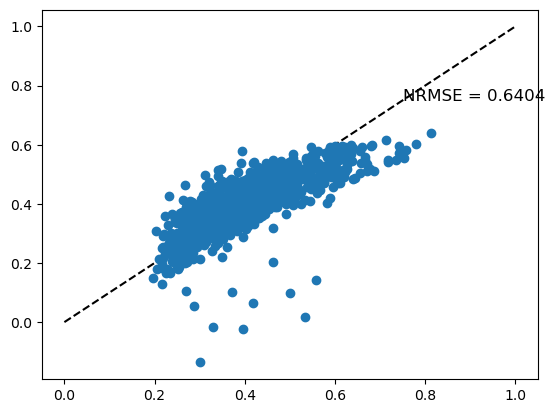

In [4]:
# NARMA10 parameters
Ntrain = 2000
Ntest = 1000
Nwarmup = 0

# Net parameters
Nvirt = 40
m0 = 1e-2
bias = True

# Reservoir parameters
h = 0.4
theta_H = 90
k_s_0 = 0
phi = 45
beta_prime = 10

# Params
params = {
    'theta':1/3, 
    'gamma':.25, 
    'delay_feedback':0, 
    'Nvirt':Nvirt,
    'noise_seed': 1234,
    'noise_train': True,
    'noise_mean_train':0.000003,
    'noise_std_train':0.000005,
    'noise_test': True,
    'noise_mean_test':0.000003,    
    'noise_std_test':0.000005,
    'seed_warmup': 1234,
    'length_warmup': Nwarmup,
    'train_sample': Ntrain*Nvirt,
    'test_sample': Ntest*Nvirt,
    'warmup_sample': Nwarmup*Nvirt,
    'value':[-0.000004,0.000006],
    'prob':[1/3,2/3]
}
spn = spnc_anisotropy(h, theta_H, k_s_0, phi, beta_prime,restart = True,Primep1=None)
transformf = spn.gen_signal_fast_delayed_feedback1   

# run
(nrmsen,y_test,y_n,y_train,s_n,net_n,x_trainn,s_trainn,x_testn,s_testn) = ml.spnc_narma10_weight(Ntrain,Ntest,Nvirt,m0,bias,transformf,params,seed_NARMA=1234,fixed_mask=True,return_all=True, Nwarmup=0)


# double check whether there is a difference between twice test

seed warmup: 1234
length warmup: 0
seed NARMA: 1234
Nwarmup: 0
Samples for training:  2000
Samples for test:  1000
Nin = 1 , Nout =  2000 , Nvirt =  40
Deterministic mask will be used
1234
current phase: warmup
p1 in warmup & slow: 0.4999998889492148
current phase: train
p1 in train & slow: 0.4999998889492148
noise_seed: 1234
noise_mean_train: 0.0001
noise-free training output
restarted
Training data size:  80000
Training data shape:  (2000, 40)
Seed Training: 1234
error with zero =  0.004380562850294669
l= 4.5399929762484854e-05 0.004456481437081064
lambda=4.5399929762484854e-05: MSE=0.004456481437081064
Current weights: [[  7.60437401]
 [  5.8876537 ]
 [ -1.04108387]
 [-16.90186923]
 [-21.76650928]
 [-21.06486875]
 [-25.81491046]
 [-37.35104418]
 [-20.96158947]
 [-16.27331111]
 [ -6.75195342]
 [ -3.57510736]
 [-18.38793318]
 [-12.24282477]
 [-18.36978005]
 [  3.57521584]
 [  3.67813362]
 [  9.84360425]
 [  3.66461435]
 [  8.00757195]
 [ -3.94882413]
 [ 15.23125359]
 [ 27.0735769 ]
 [

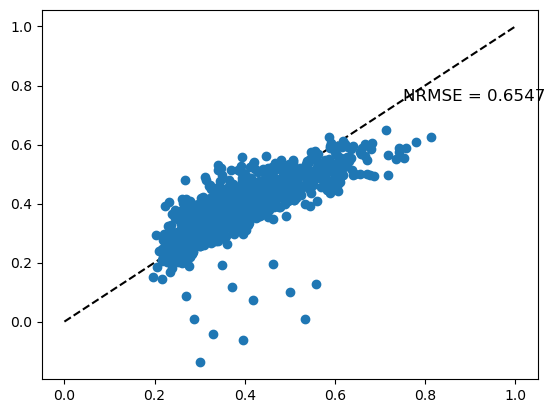

seed warmup: 1234
length warmup: 0
seed NARMA: 1234
Nwarmup: 0
Samples for training:  2000
Samples for test:  1000
Nin = 1 , Nout =  2000 , Nvirt =  40
Deterministic mask will be used
1234
current phase: warmup
p1 in warmup & fast: 0.4999998889492148
current phase: train
p1 in train & fast: 0.4999998889492148
noise-free training output
restarted
Training data size:  80000
Training data shape:  (2000, 40)
Seed Training: 1234
error with zero =  0.0033847981091504574
l= 4.5399929762484854e-05 0.004384336979609115
lambda=4.5399929762484854e-05: MSE=0.004384336979609115
Current weights: [[ 7.47991004e+00]
 [ 8.27565224e+00]
 [-3.06756574e-01]
 [-1.21994233e+01]
 [-2.13063731e+01]
 [-2.56746877e+01]
 [-2.55483963e+01]
 [-3.79817057e+01]
 [-2.32792837e+01]
 [-1.36198407e+01]
 [-8.84363084e+00]
 [-5.26589997e+00]
 [-1.71737374e+01]
 [-1.90104753e+01]
 [-1.68070746e+01]
 [-8.61817048e-03]
 [ 5.22930017e+00]
 [ 5.47756773e+00]
 [ 6.79356102e+00]
 [ 1.08497464e+01]
 [ 1.29891020e+00]
 [ 1.7819400

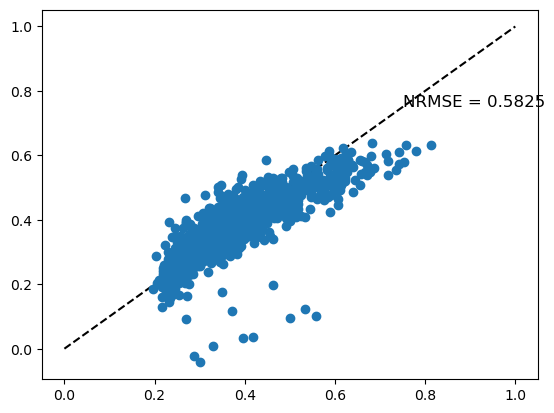

seed warmup: 1234
length warmup: 0
seed NARMA: 1234
Nwarmup: 0
Samples for training:  2000
Samples for test:  1000
Nin = 1 , Nout =  2000 , Nvirt =  40
Deterministic mask will be used
1234
current phase: warmup
p1 in warmup & slow: 0.4999998889492148
current phase: train
p1 in train & slow: 0.4999998889492148
noise_seed: 1234
noise_mean_train: 0.0001
noise-free training output
restarted
Training data size:  80000
Training data shape:  (2000, 40)
Seed Training: 1234
error with zero =  0.004380562850294669
l= 4.5399929762484854e-05 0.004456481437081064
lambda=4.5399929762484854e-05: MSE=0.004456481437081064
Current weights: [[  7.60437401]
 [  5.8876537 ]
 [ -1.04108387]
 [-16.90186923]
 [-21.76650928]
 [-21.06486875]
 [-25.81491046]
 [-37.35104418]
 [-20.96158947]
 [-16.27331111]
 [ -6.75195342]
 [ -3.57510736]
 [-18.38793318]
 [-12.24282477]
 [-18.36978005]
 [  3.57521584]
 [  3.67813362]
 [  9.84360425]
 [  3.66461435]
 [  8.00757195]
 [ -3.94882413]
 [ 15.23125359]
 [ 27.0735769 ]
 [

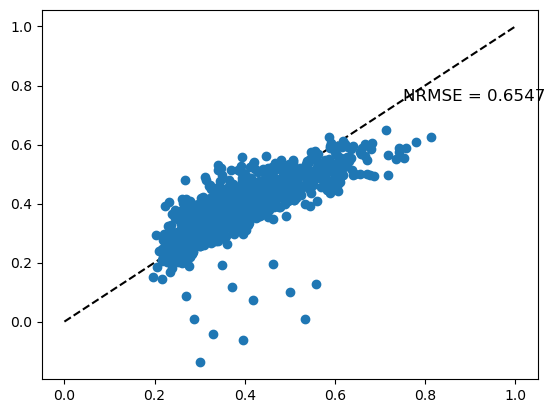

seed warmup: 1234
length warmup: 0
seed NARMA: 1234
Nwarmup: 0
Samples for training:  2000
Samples for test:  1000
Nin = 1 , Nout =  2000 , Nvirt =  40
Deterministic mask will be used
1234
current phase: warmup
p1 in warmup & fast: 0.4999998889492148
current phase: train
p1 in train & fast: 0.4999998889492148
noise-free training output
restarted
Training data size:  80000
Training data shape:  (2000, 40)
Seed Training: 1234
error with zero =  0.0033847981091504574
l= 4.5399929762484854e-05 0.004384336979609115
lambda=4.5399929762484854e-05: MSE=0.004384336979609115
Current weights: [[ 7.47991004e+00]
 [ 8.27565224e+00]
 [-3.06756574e-01]
 [-1.21994233e+01]
 [-2.13063731e+01]
 [-2.56746877e+01]
 [-2.55483963e+01]
 [-3.79817057e+01]
 [-2.32792837e+01]
 [-1.36198407e+01]
 [-8.84363084e+00]
 [-5.26589997e+00]
 [-1.71737374e+01]
 [-1.90104753e+01]
 [-1.68070746e+01]
 [-8.61817048e-03]
 [ 5.22930017e+00]
 [ 5.47756773e+00]
 [ 6.79356102e+00]
 [ 1.08497464e+01]
 [ 1.29891020e+00]
 [ 1.7819400

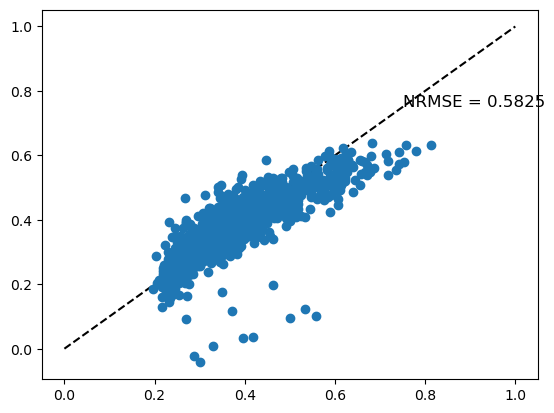

In [5]:
# NARMA10 parameters
Ntrain = 2000
Ntest = 1000
Nwarmup = 0

# Net parameters
Nvirt = 40
m0 = 1e-2
bias = True

# Reservoir parameters
h = 0.4
theta_H = 90
k_s_0 = 0
phi = 45
beta_prime = 10

# Params
params = {
    'theta':1/3, 
    'gamma':.25, 
    'delay_feedback':0, 
    'Nvirt':Nvirt,
    'noise_enable': 'None',
    'noise_seed': 1234,
    'noise_mean':0.0001,
    'noise_std':0.00013,
    'seed_warmup': 1234,
    'length_warmup': Nwarmup,
    'train_sample': Ntrain*Nvirt,
    'test_sample': Ntest*Nvirt,
    'warmup_sample': Nwarmup*Nvirt,
}

spn = spnc_anisotropy(h, theta_H, k_s_0, phi, beta_prime,restart = True,Primep1=None)
transforms = spn.gen_signal_slow_delayed_feedback   
transformf = spn.gen_signal_fast_delayed_feedback

# run
(_,_,_,_,_,net_s1,x_trains1,s_trains1,_,_) = ml.spnc_narma10_weight(Ntrain,Ntest,Nvirt,m0,bias,transforms,params,seed_NARMA=1234,fixed_mask=True,return_all=True, Nwarmup=0)
(_,_,_,_,_,net_f1,x_trainf1,s_trainf1,_,_) = ml.spnc_narma10_weight(Ntrain,Ntest,Nvirt,m0,bias,transformf,params,seed_NARMA=1234,fixed_mask=True,return_all=True, Nwarmup=0)

# run twice

(_,_,_,_,_,net_s2,x_trains2,s_trains2,_,_) = ml.spnc_narma10_weight(Ntrain,Ntest,Nvirt,m0,bias,transforms,params,seed_NARMA=1234,fixed_mask=True,return_all=True, Nwarmup=0)
(_,_,_,_,_,net_f2,x_trainf2,s_trainf2,_,_) = ml.spnc_narma10_weight(Ntrain,Ntest,Nvirt,m0,bias,transformf,params,seed_NARMA=1234,fixed_mask=True,return_all=True, Nwarmup=0)


In [6]:
print(np.shape(s_trains1))
print(np.shape(s_trainf1))
print(np.shape(s_trains2))
print(np.shape(s_trainf2))

(2000, 40)
(2000, 40)
(2000, 40)
(2000, 40)


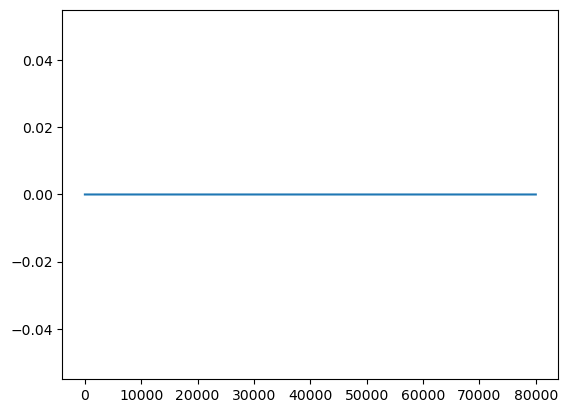

0.0
0.0


In [8]:
flat_s1 = np.array(s_trains1).flatten() 
flat_f1 = np.array(s_trainf1).flatten()
flat_s2 = np.array(s_trains2).flatten()
flat_f2 = np.array(s_trainf2).flatten()

dif = flat_s1 - flat_s2

nrmses = NRMSE_list(flat_s1,flat_s2)
nrmsesf = NRMSE_list(flat_f1,flat_f2)

plt.figure()
plt.plot(dif)
plt.show()


print(nrmses)
print(nrmsesf)